In [3]:
#Modify the path to a directory on your machine
import os
os.environ["CRDS_PATH"] = "/home/hailin/Documents/CRDS"
os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"

# Packages that allow us to get information about objects:
import asdf
import copy
import shutil

# Numpy library:
import numpy as np

# For downloading data
import requests

# Astropy tools:
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.visualization import ImageNormalize, ManualInterval, LogStretch

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
import matplotlib as mpl
import matplotlib.ticker as ticker

# Use this version for non-interactive plots (easier scrolling of the notebook)
%matplotlib inline

# Use this version (outside of Jupyter Lab) if you want interactive plots
#%matplotlib notebook

# List of possible data quality flags
from jwst.datamodels import dqflags

# The entire calwebb_detector1 pipeline
from jwst.pipeline import calwebb_detector1

# Individual steps that make up calwebb_detector1
from jwst.dq_init import DQInitStep
from jwst.saturation import SaturationStep
from jwst.superbias import SuperBiasStep
from jwst.ipc import IPCStep                                                                                    
from jwst.refpix import RefPixStep                                                                
from jwst.linearity import LinearityStep
from jwst.persistence import PersistenceStep
from jwst.dark_current import DarkCurrentStep
from jwst.jump import JumpStep
from jwst.ramp_fitting import RampFitStep
from jwst import datamodels

import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.special import gamma
from scipy.optimize import curve_fit, minimize
import math
from scipy.stats import chisquare
from scipy.stats import chi2
from pathlib import Path

import jwst
print(jwst.__version__)

def gaussian(x, mean, stddev):
    return  np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) / stddev / np.sqrt(2*np.pi)
def poisson(x, lambda_param):
    return np.exp(-lambda_param) * np.power(lambda_param, x) / gamma(x+1) #if not lambda_param < 1e-9 else
def log_poisson(x, lambda_param):
    if x > 0:
        return x * np.log(lambda_param) - lambda_param - (x*np.log(x) - x + np.log(2*np.pi*x)/2 + 1/12/x)  # 这 lambda_param 不能是0。如果很小，结果很负，摆动很大，注意。log(N!) = N*log(N) - N + log(2pi N)/2 + 1/12/N - ...
    else:
        return -lambda_param

1.15.1


109.85025964458964


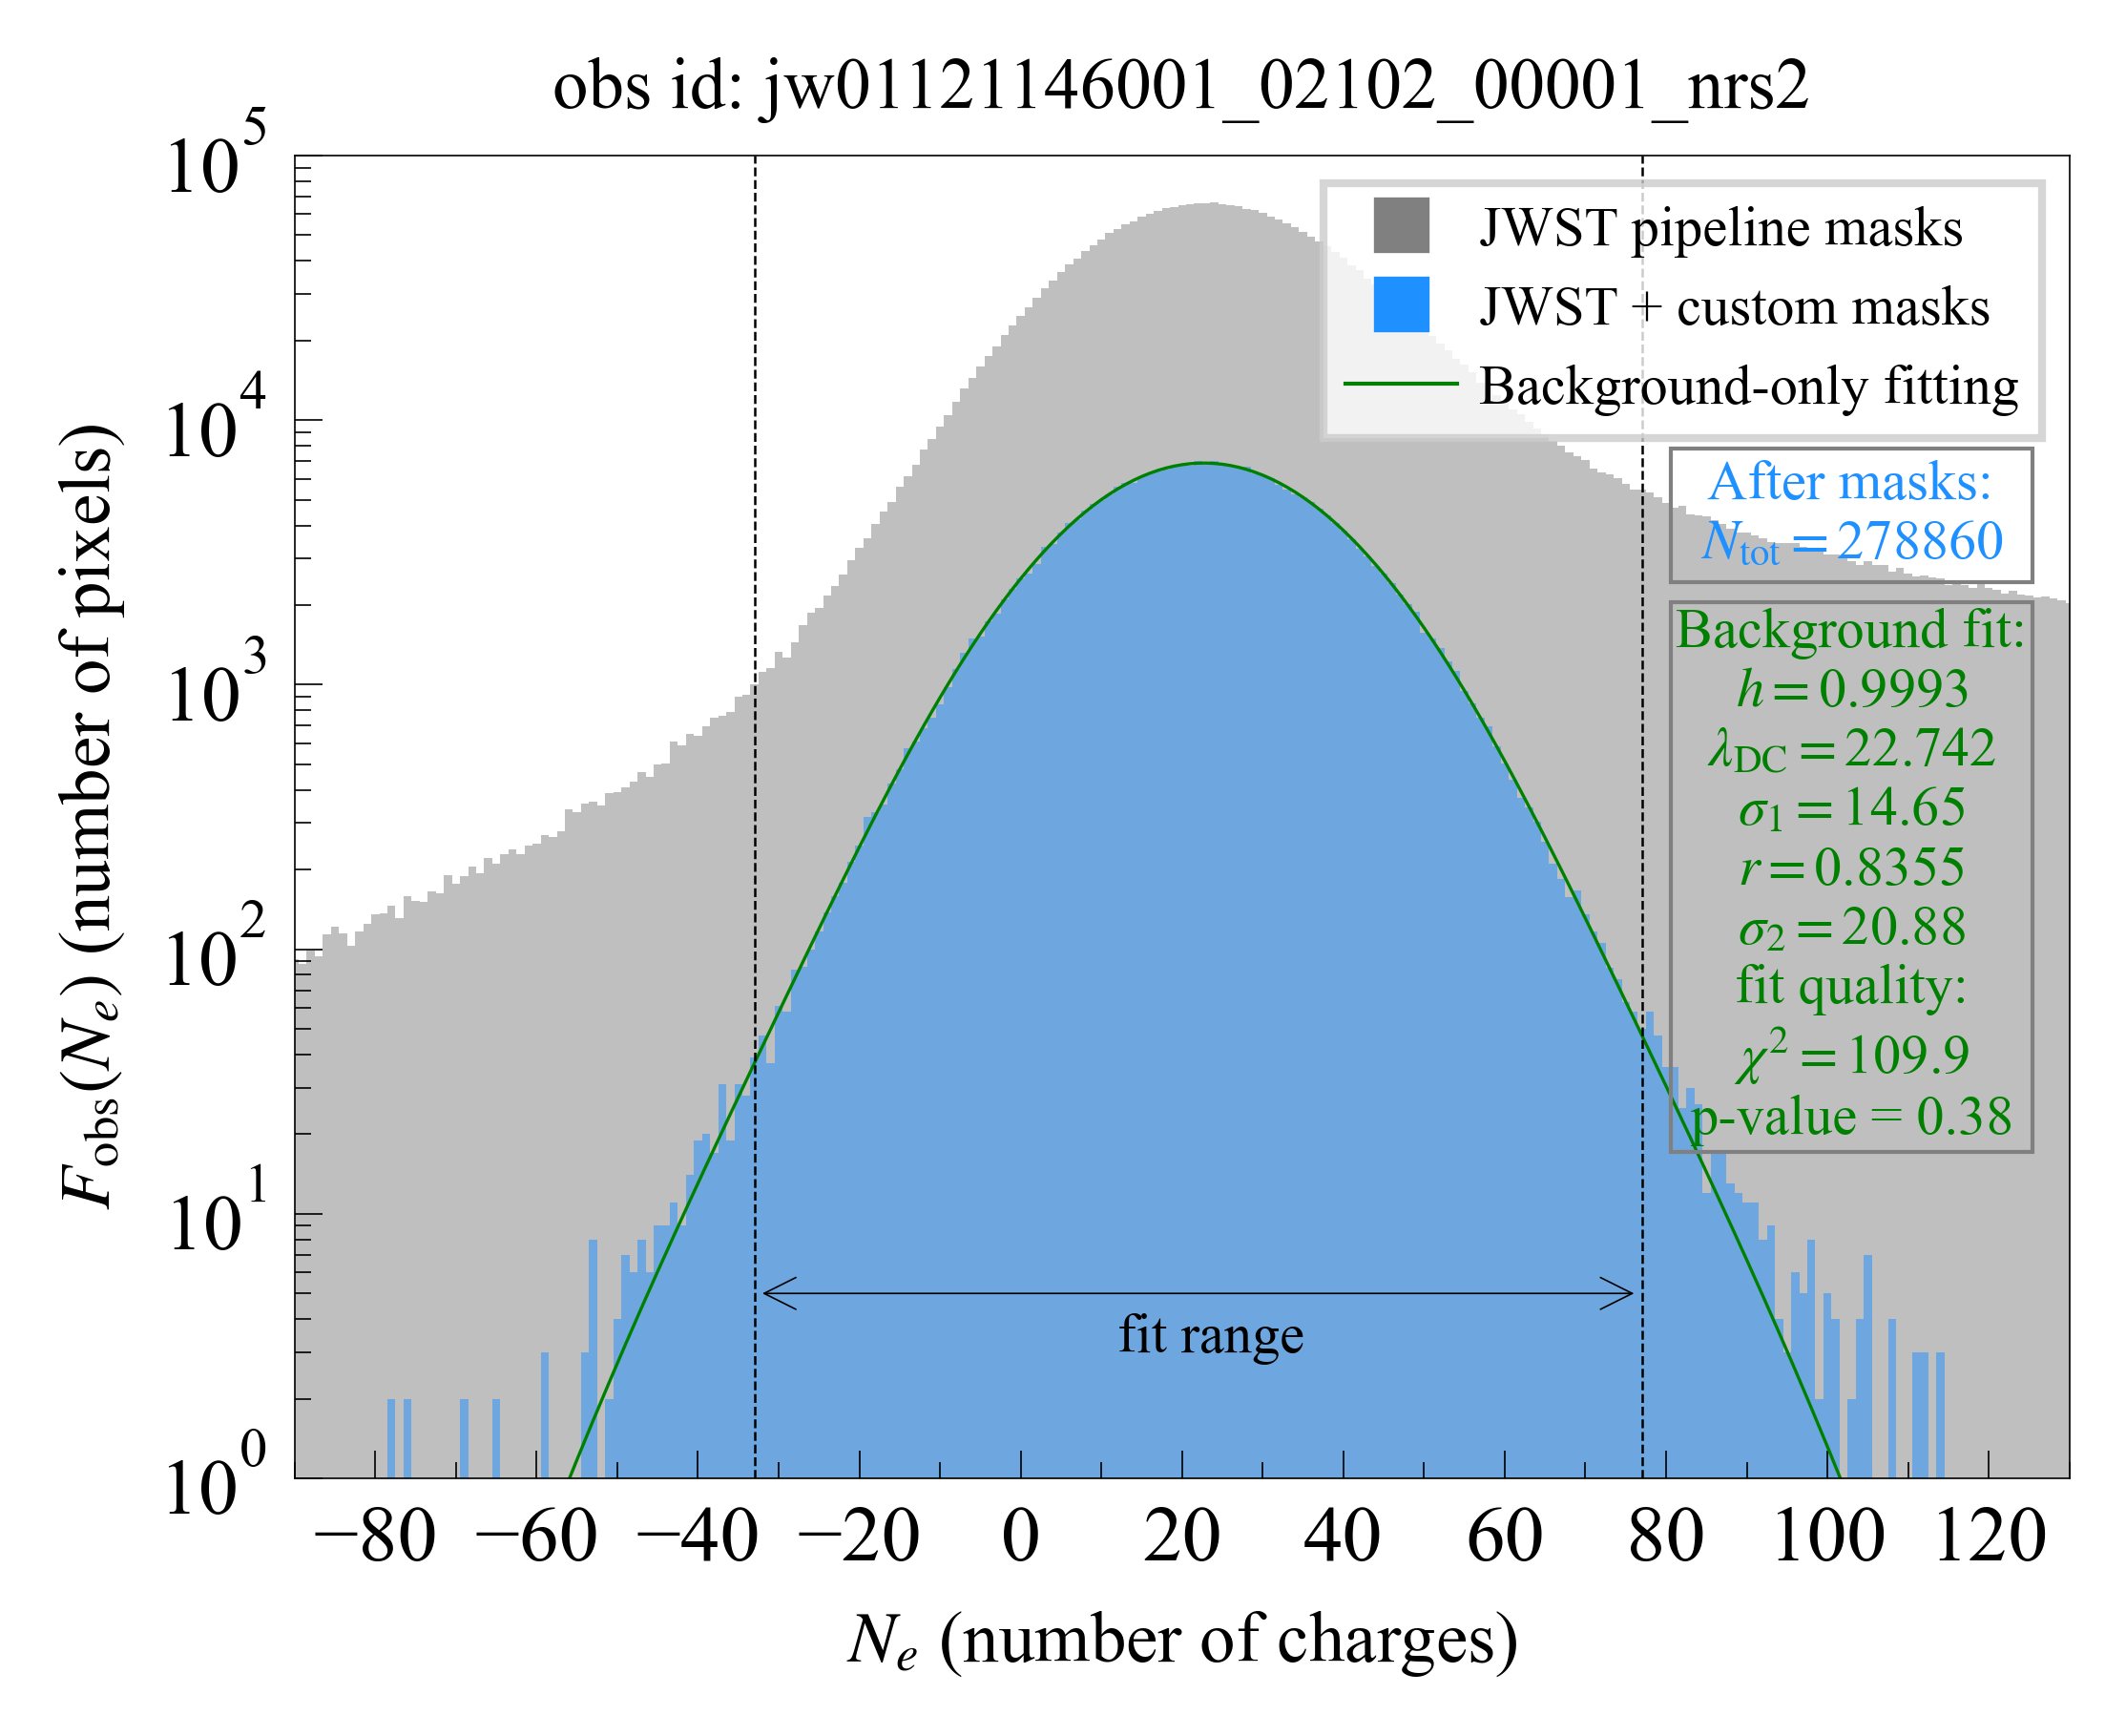

jw01121146001_02102_00001_nrs2 analysis completed
116.58565131849993


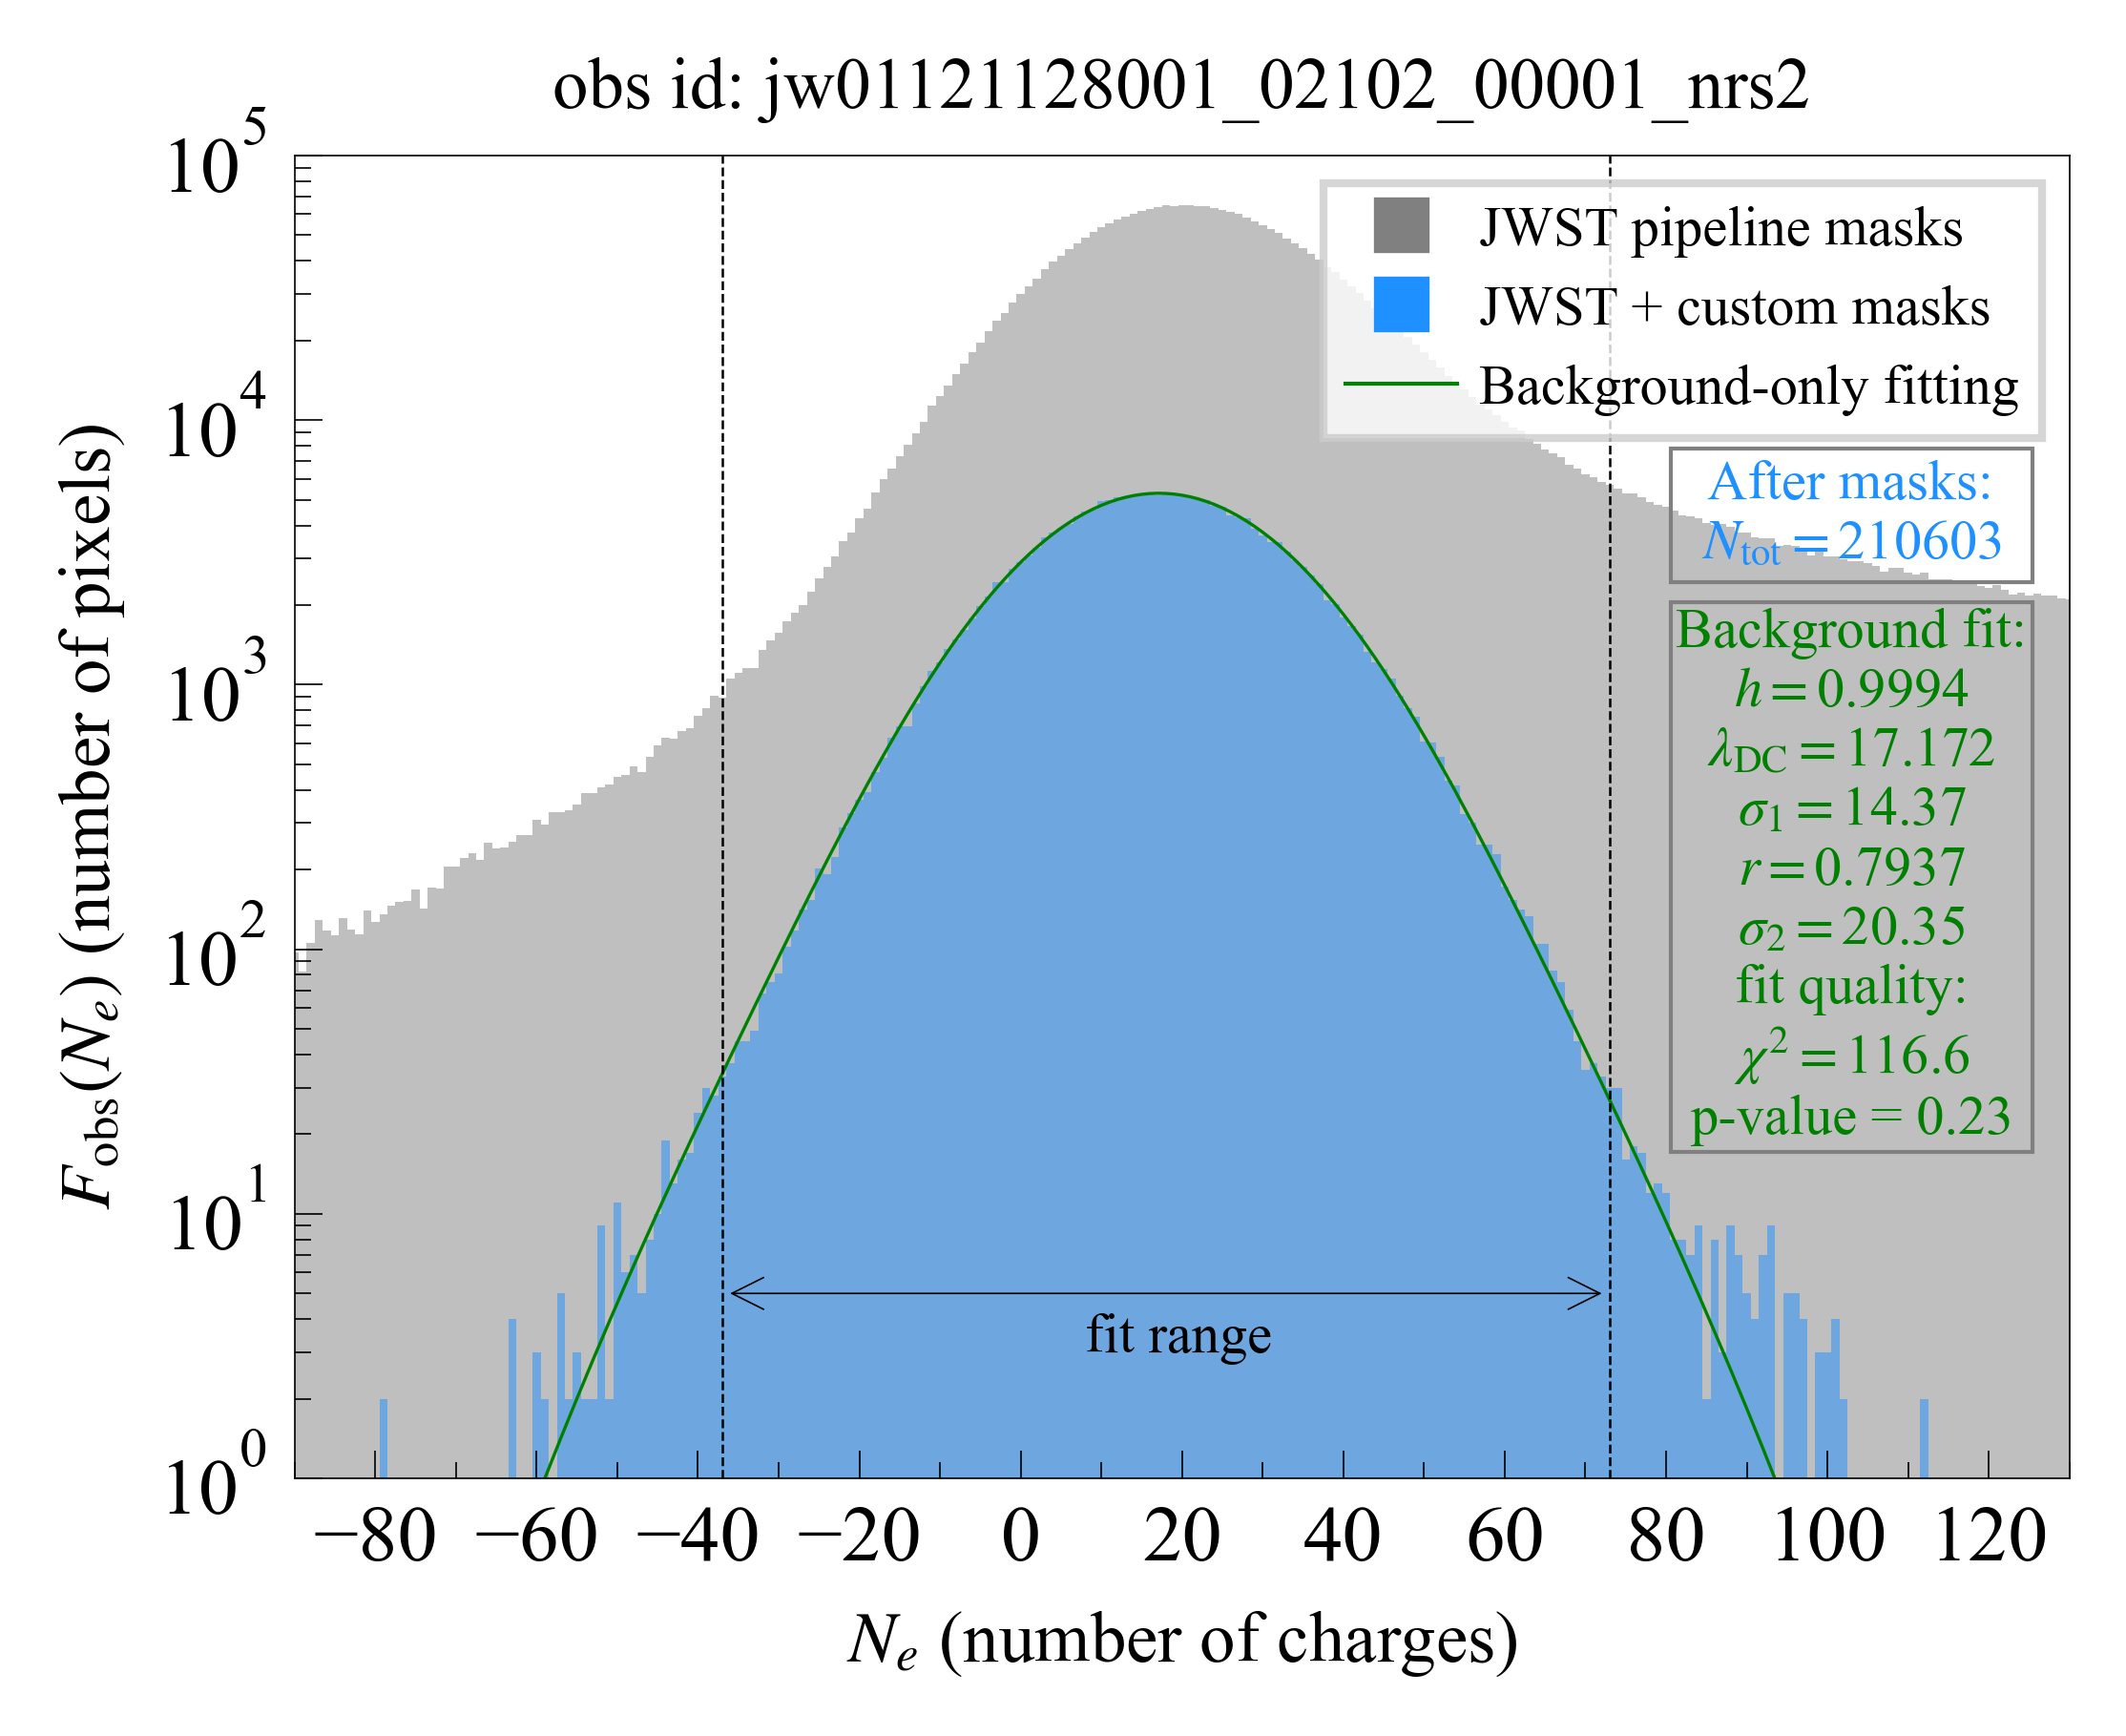

jw01121128001_02102_00001_nrs2 analysis completed
117.49984775863591


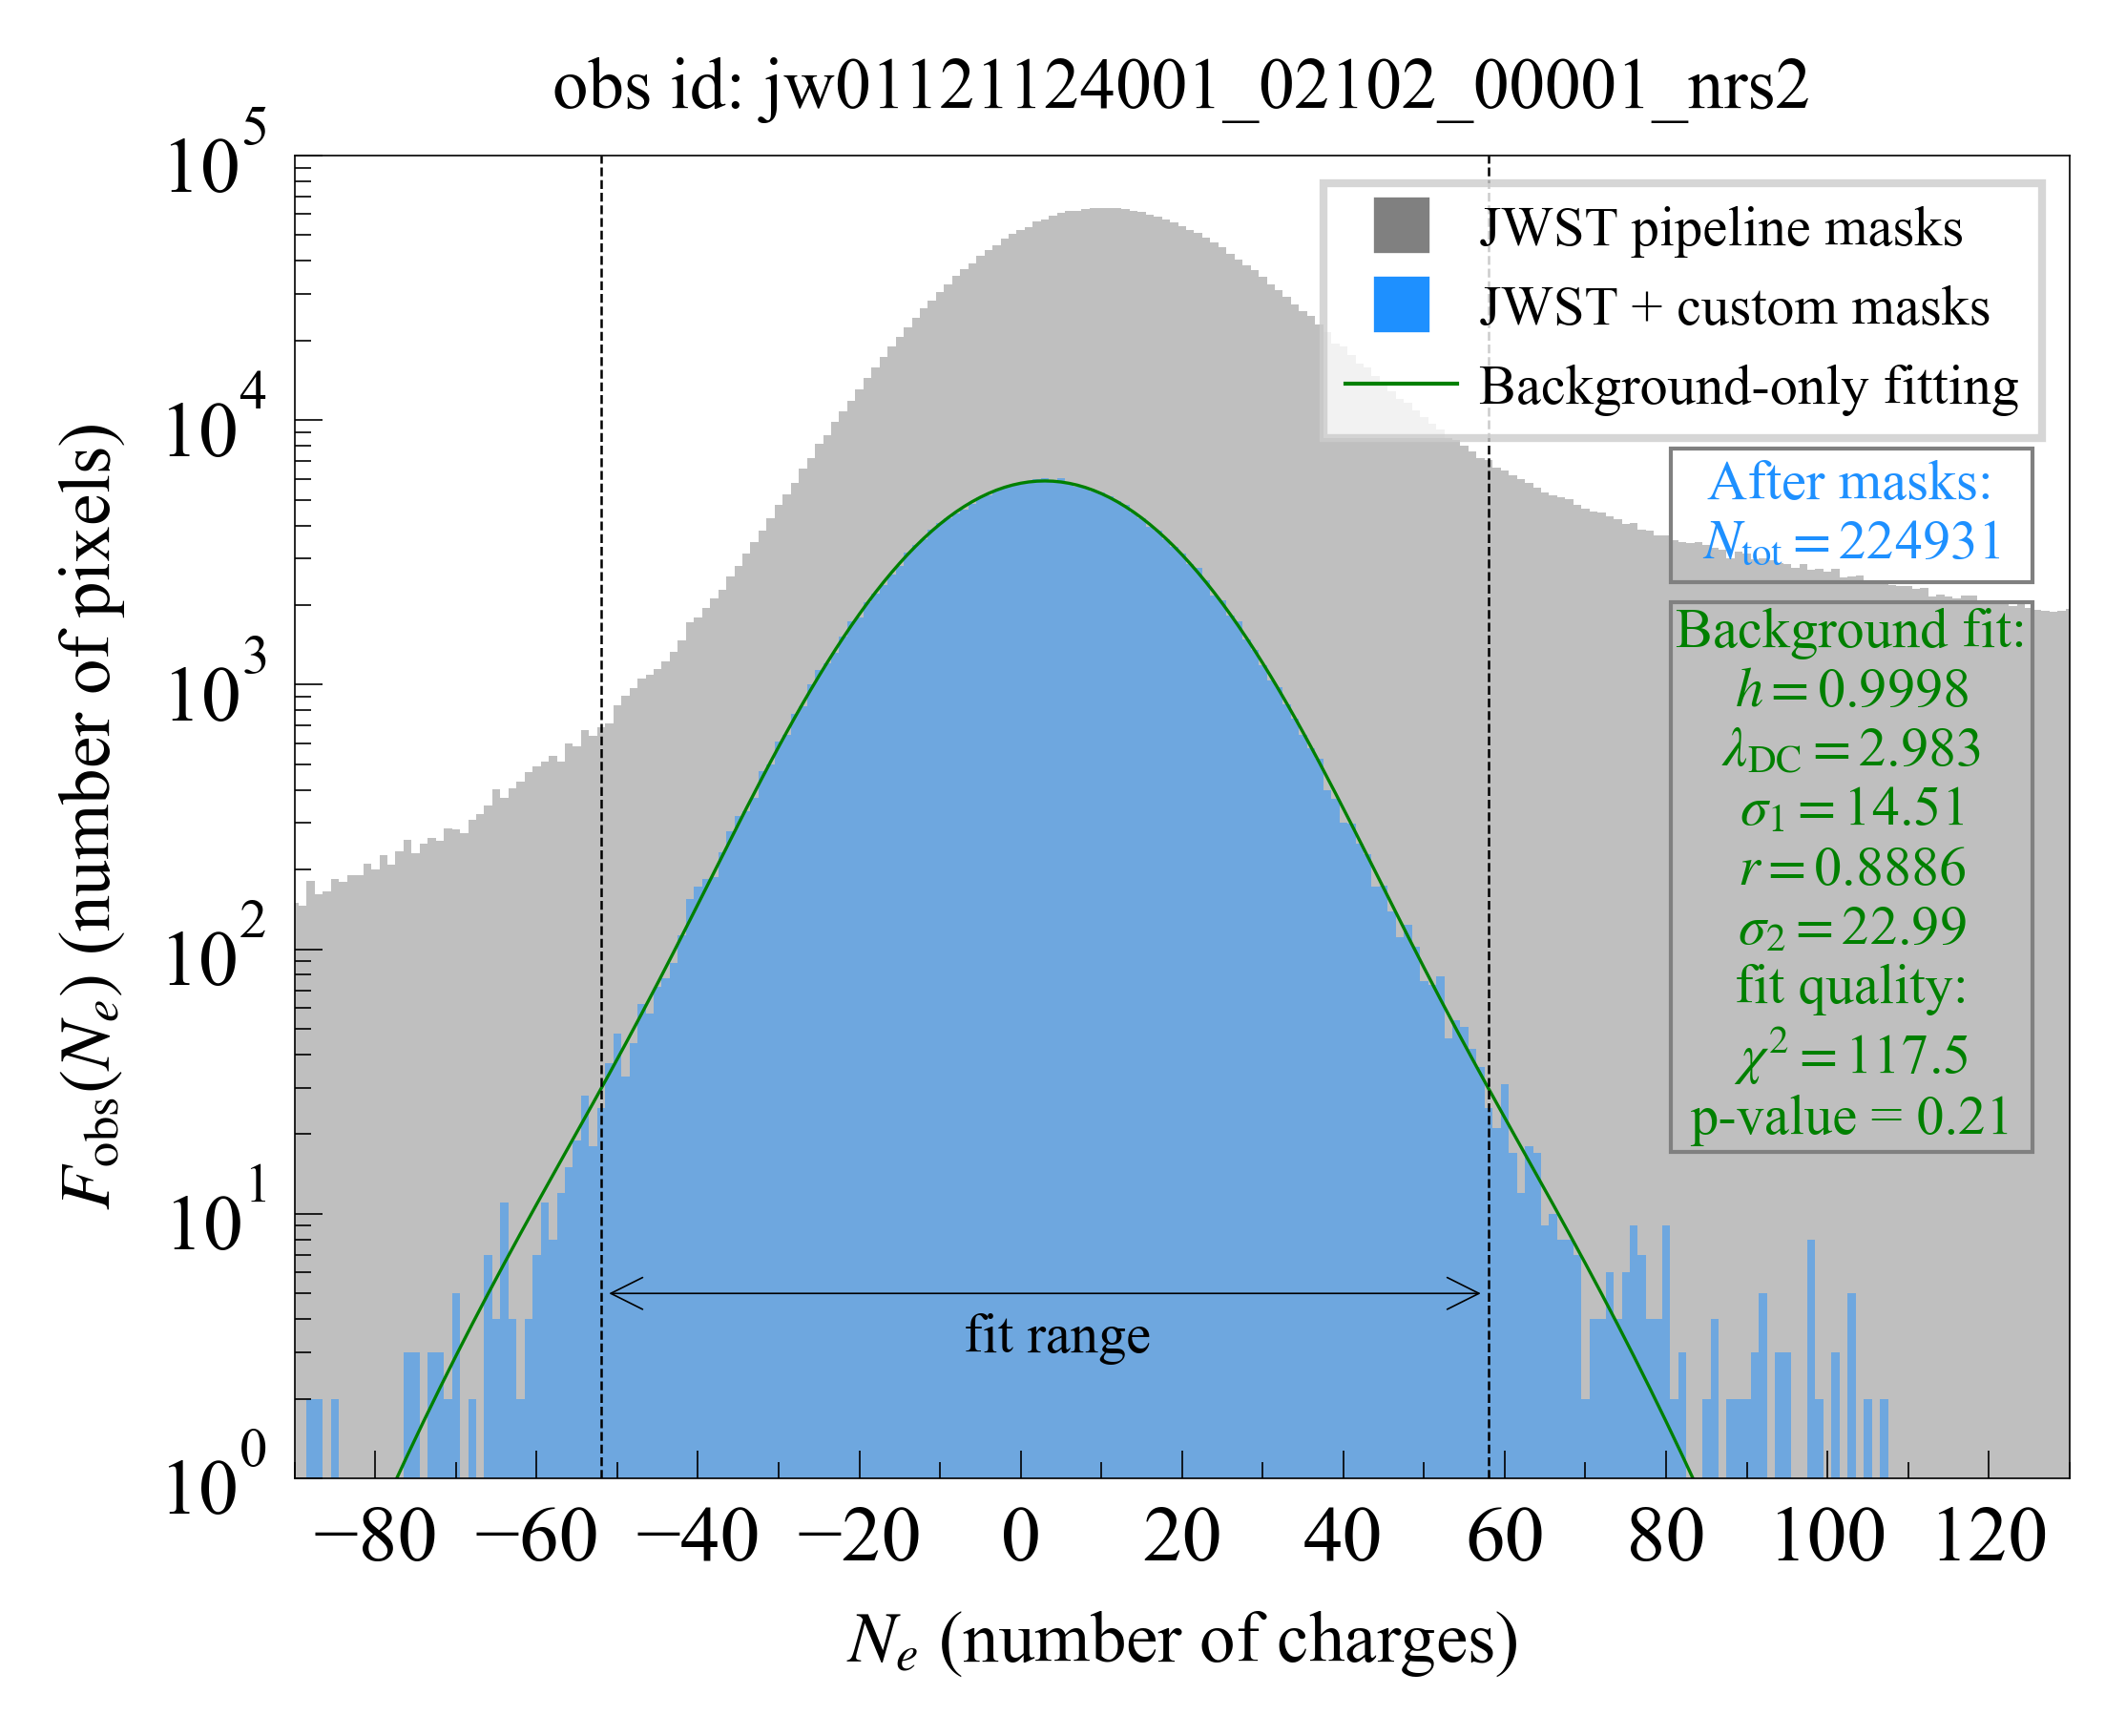

jw01121124001_02102_00001_nrs2 analysis completed
97.40813855145687


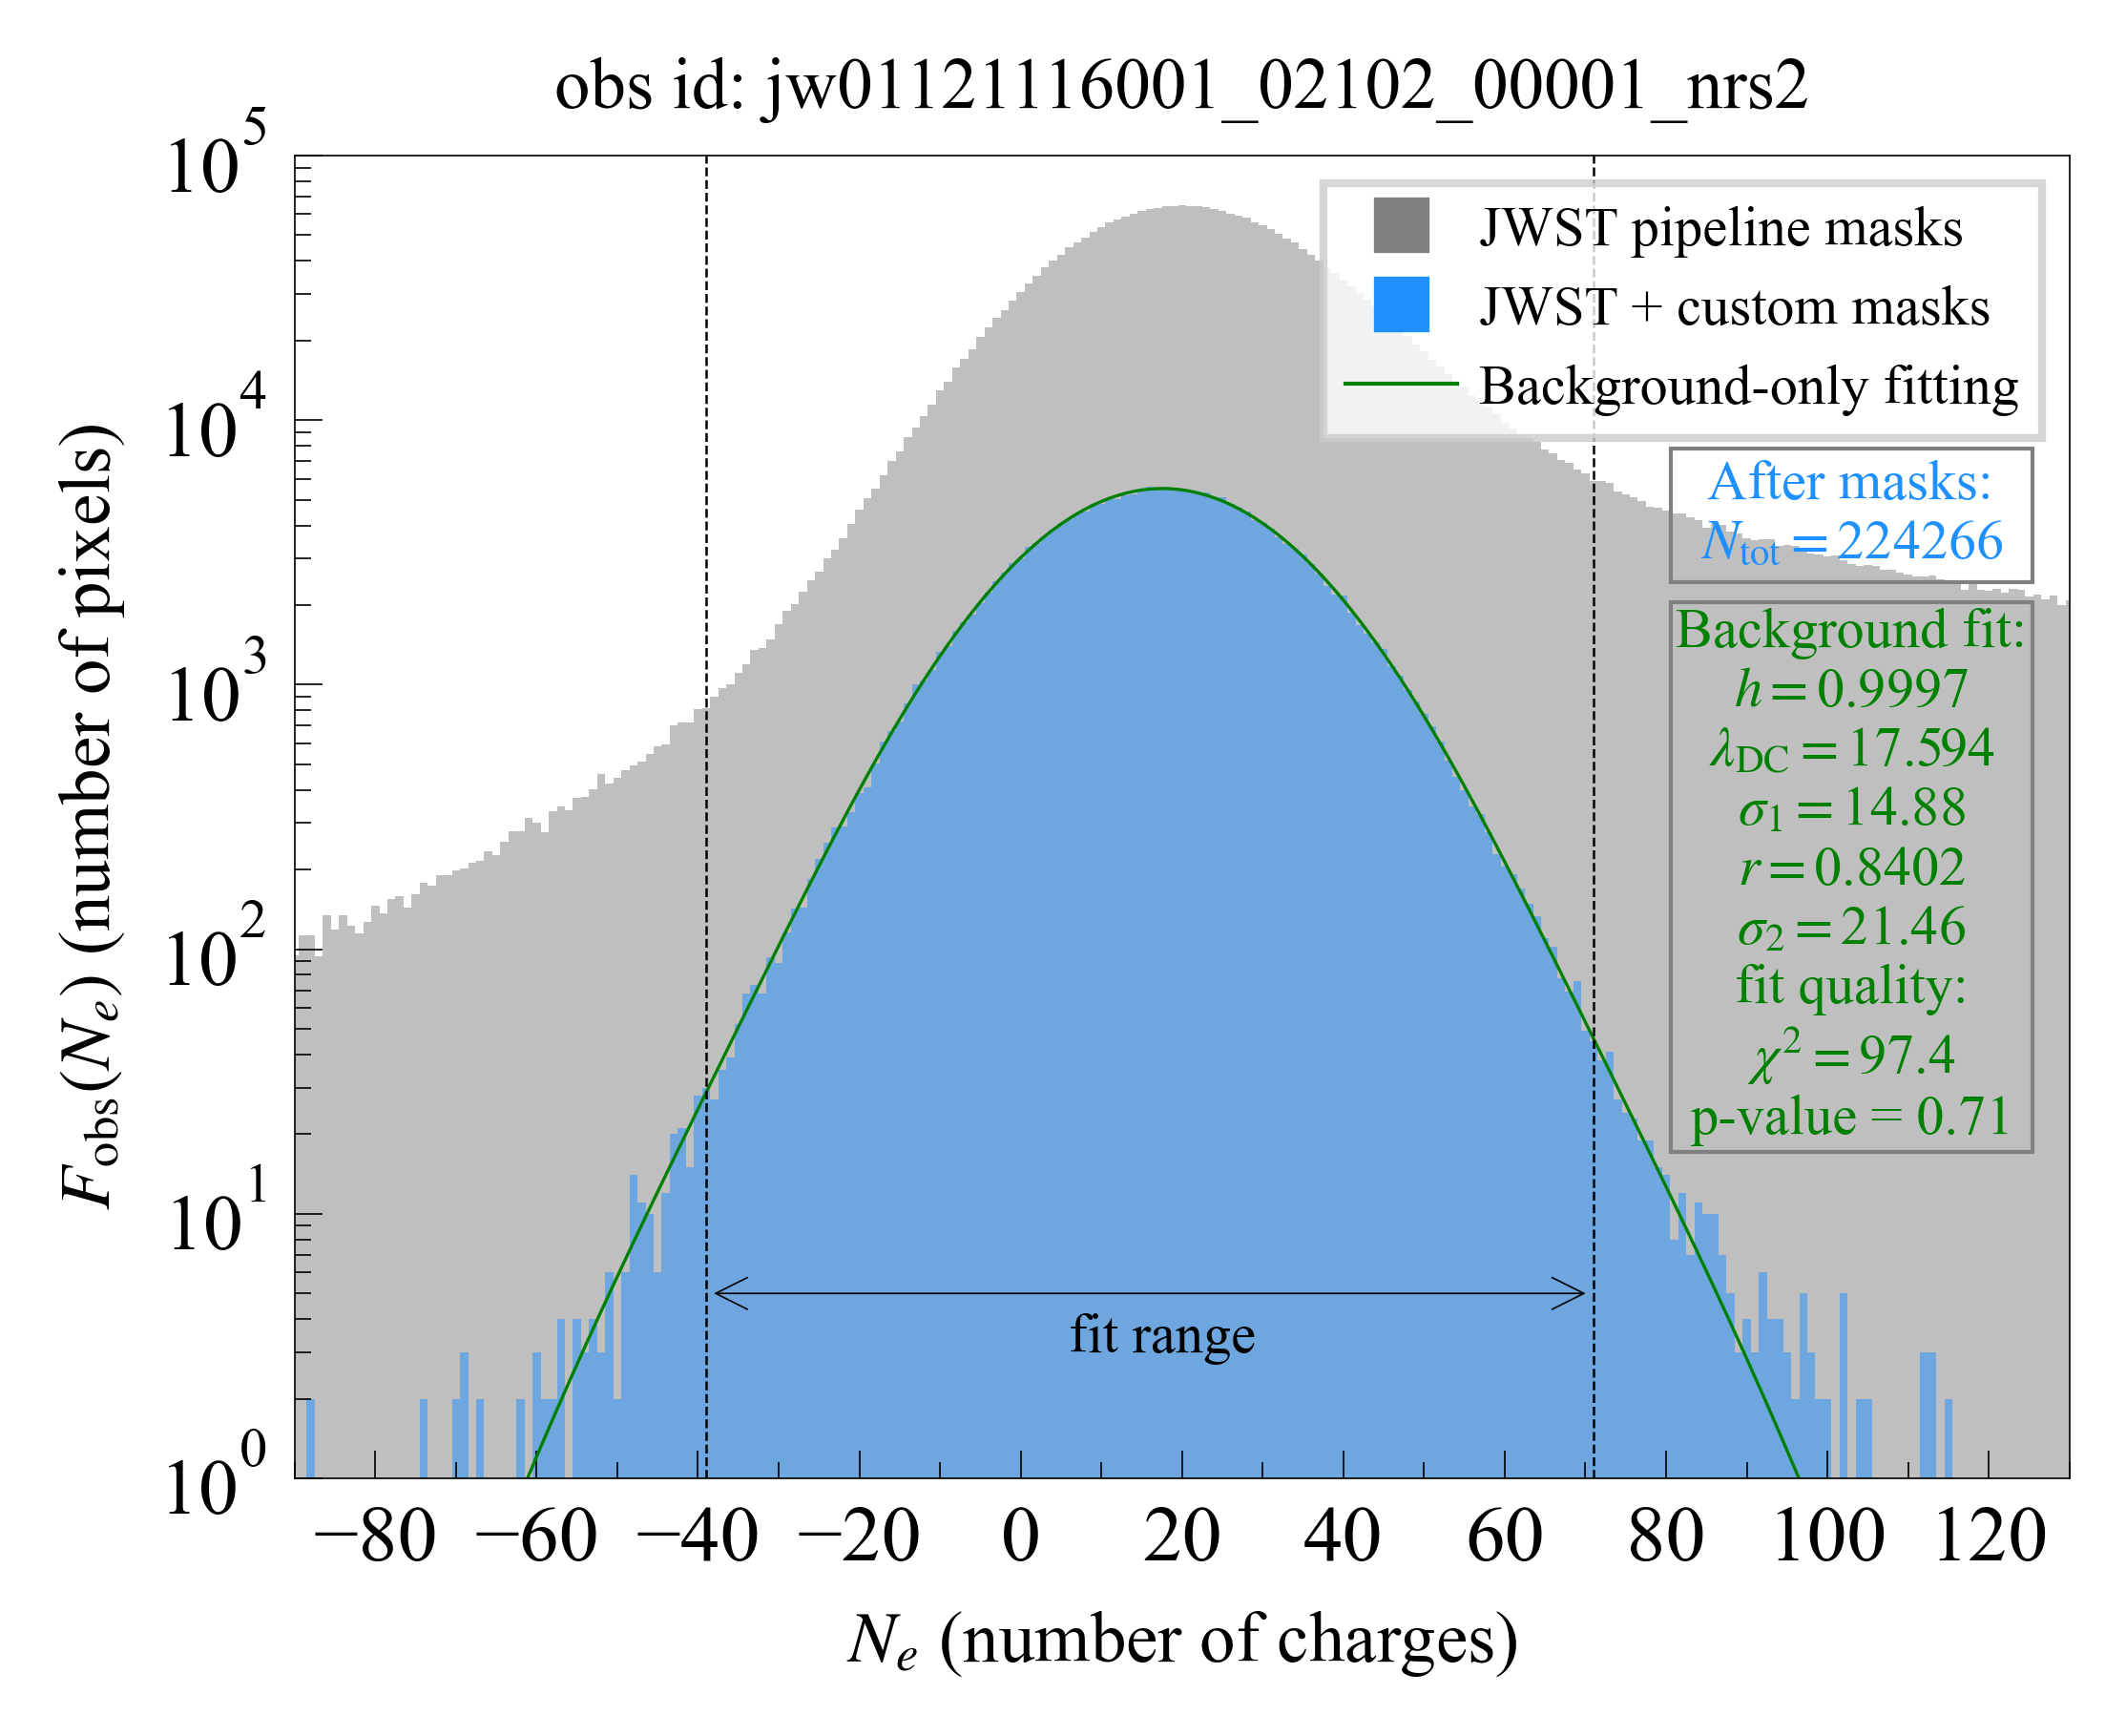

jw01121116001_02102_00001_nrs2 analysis completed
106.27406006028517


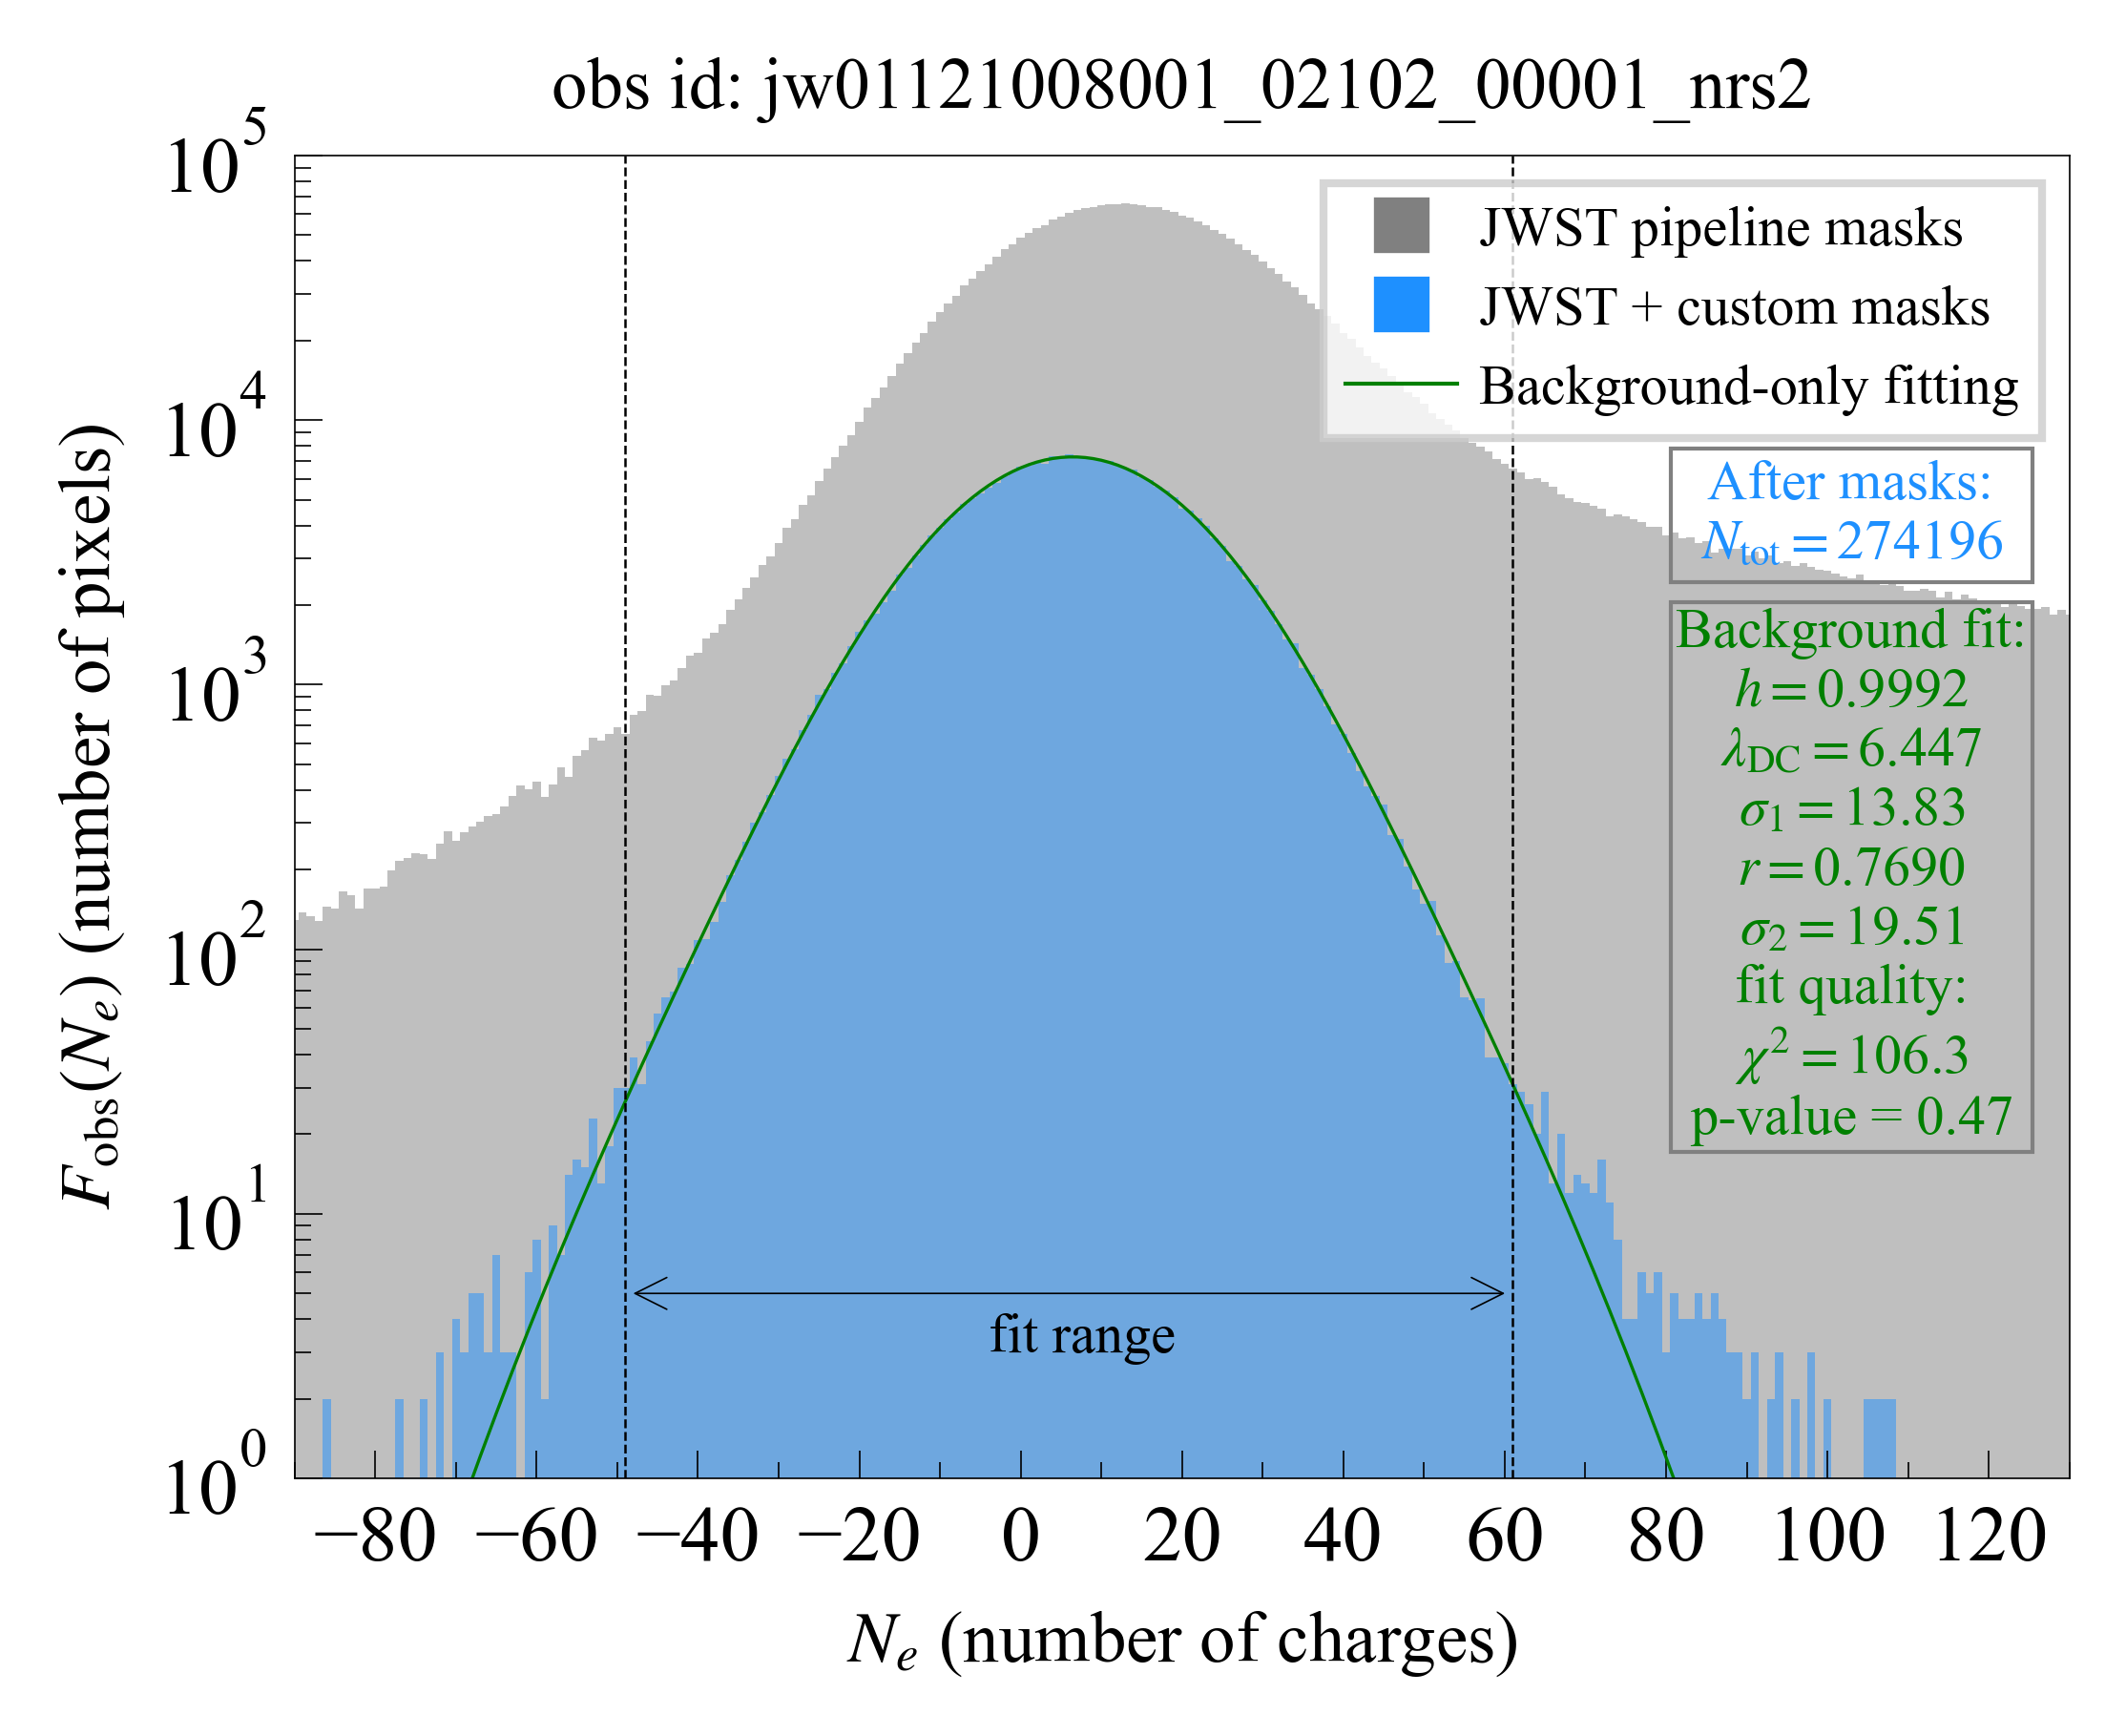

jw01121008001_02102_00001_nrs2 analysis completed
102.6744872605992


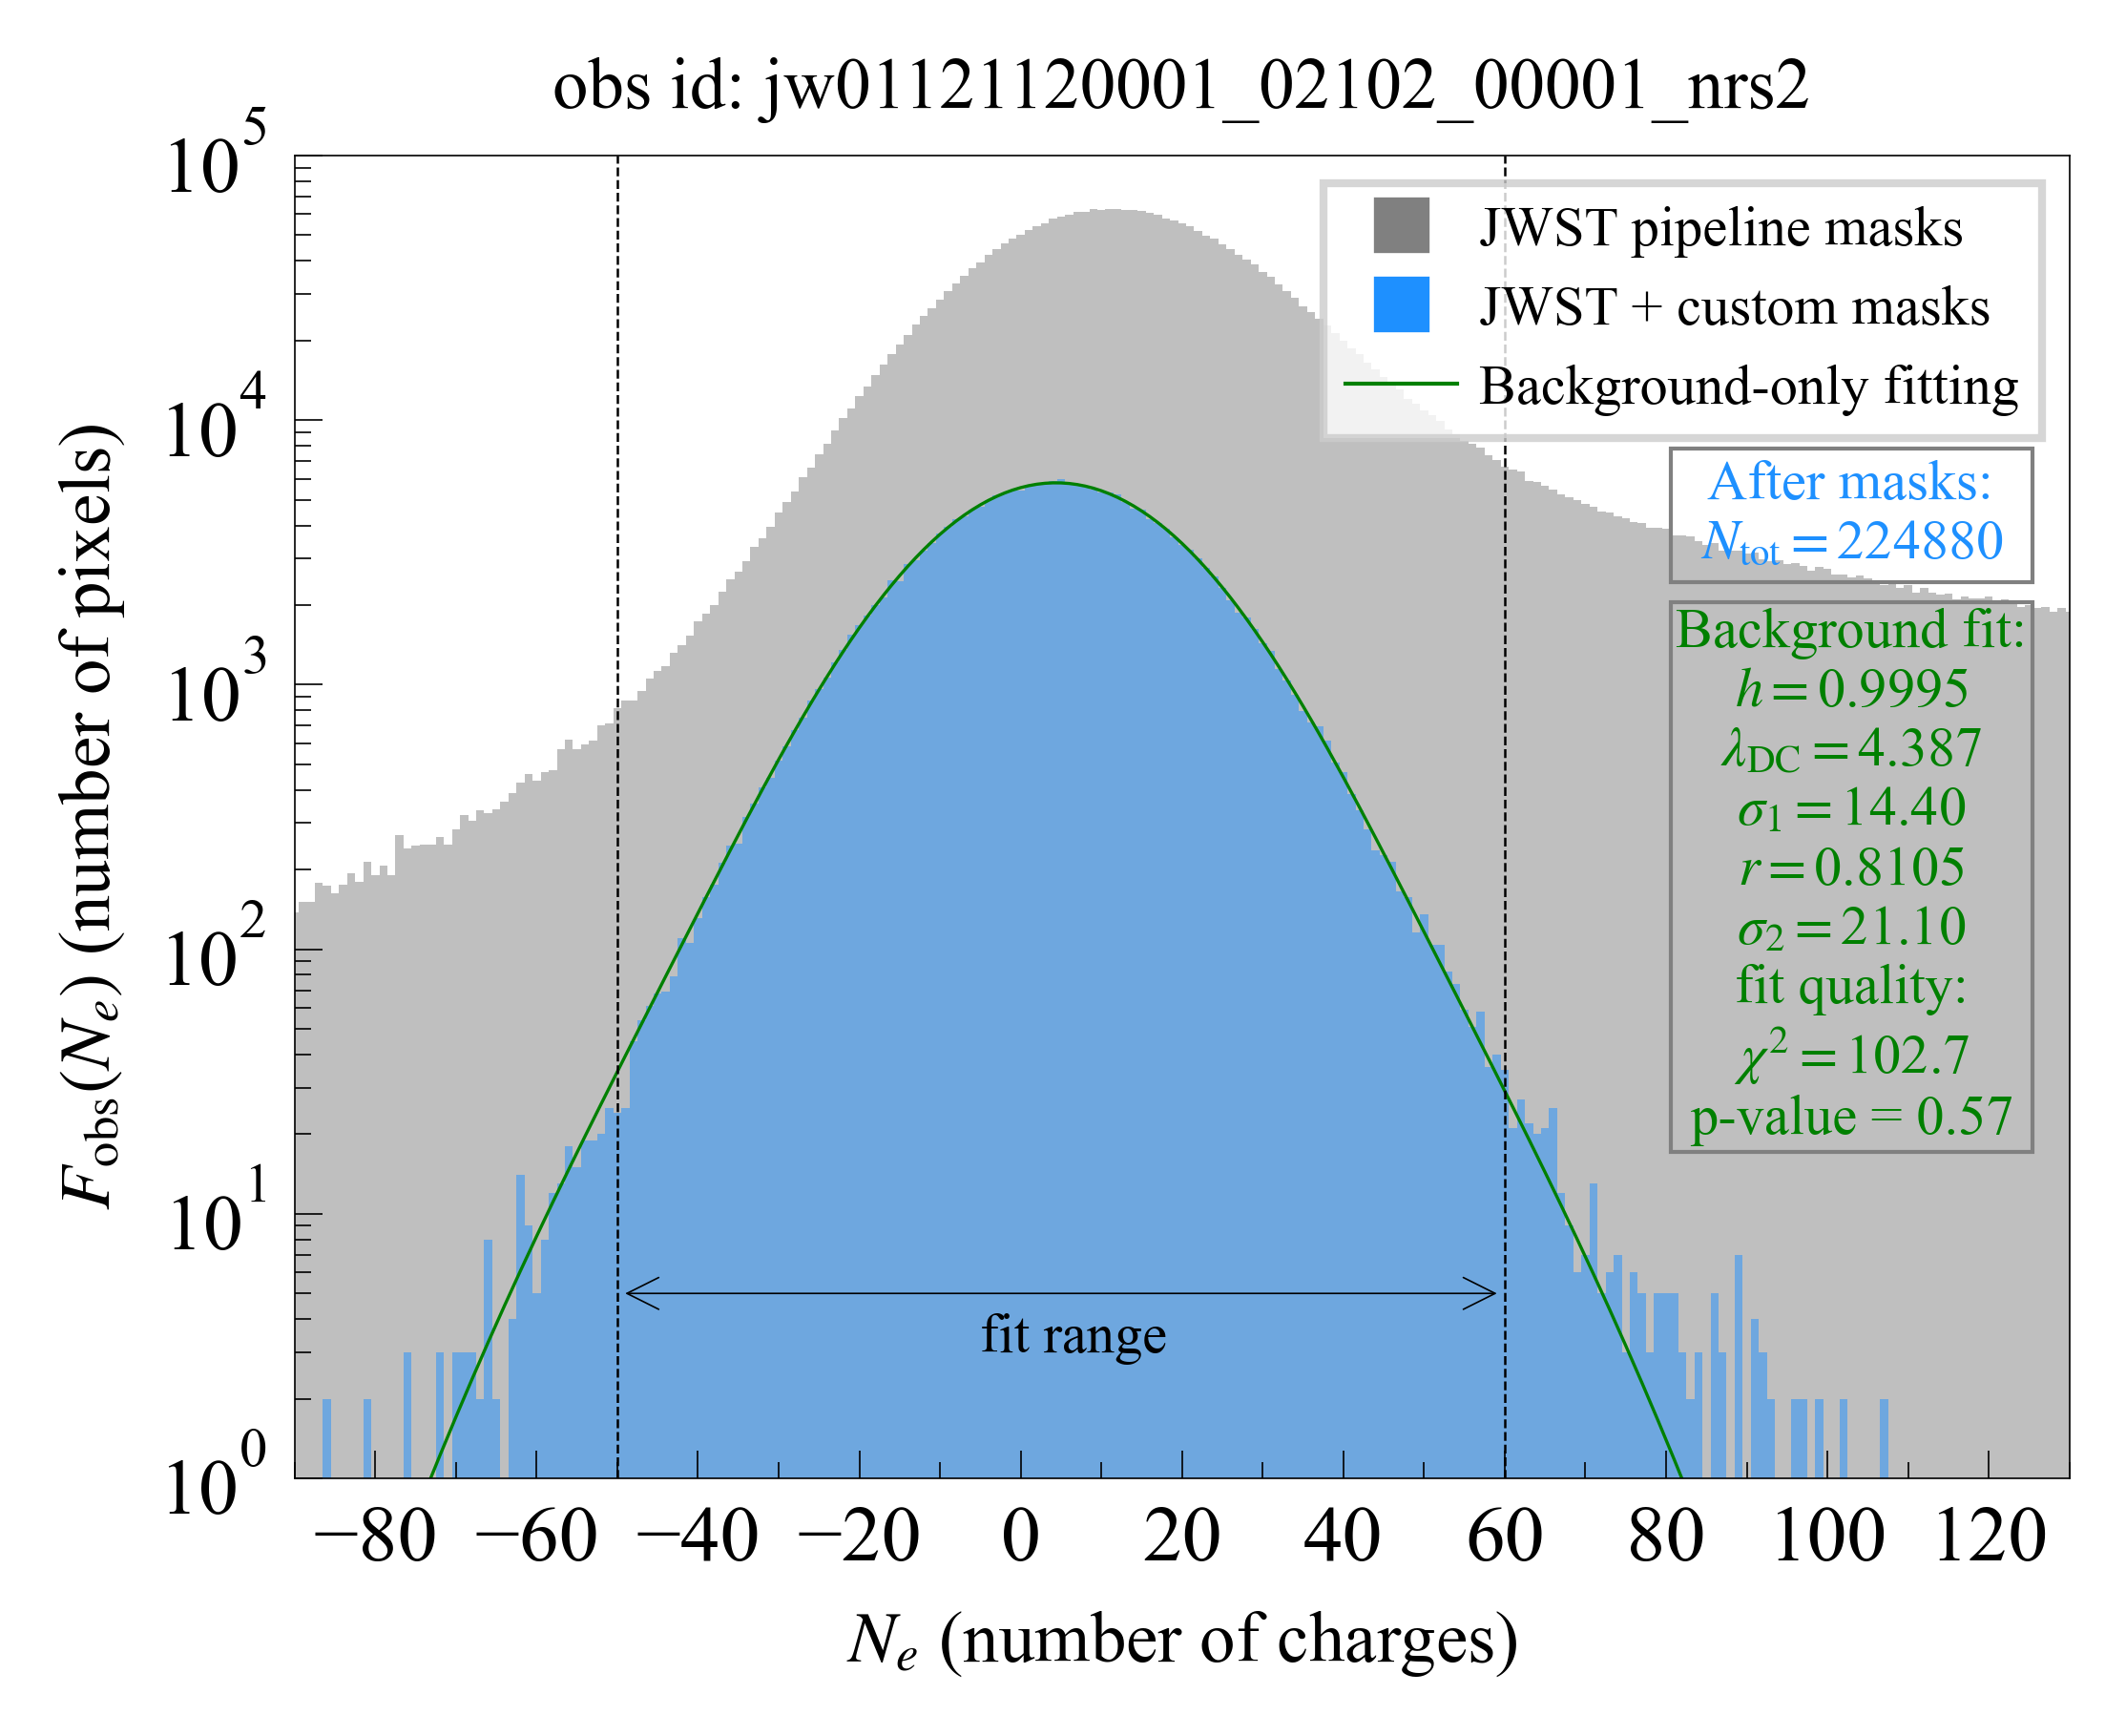

jw01121120001_02102_00001_nrs2 analysis completed
96.4844716661505


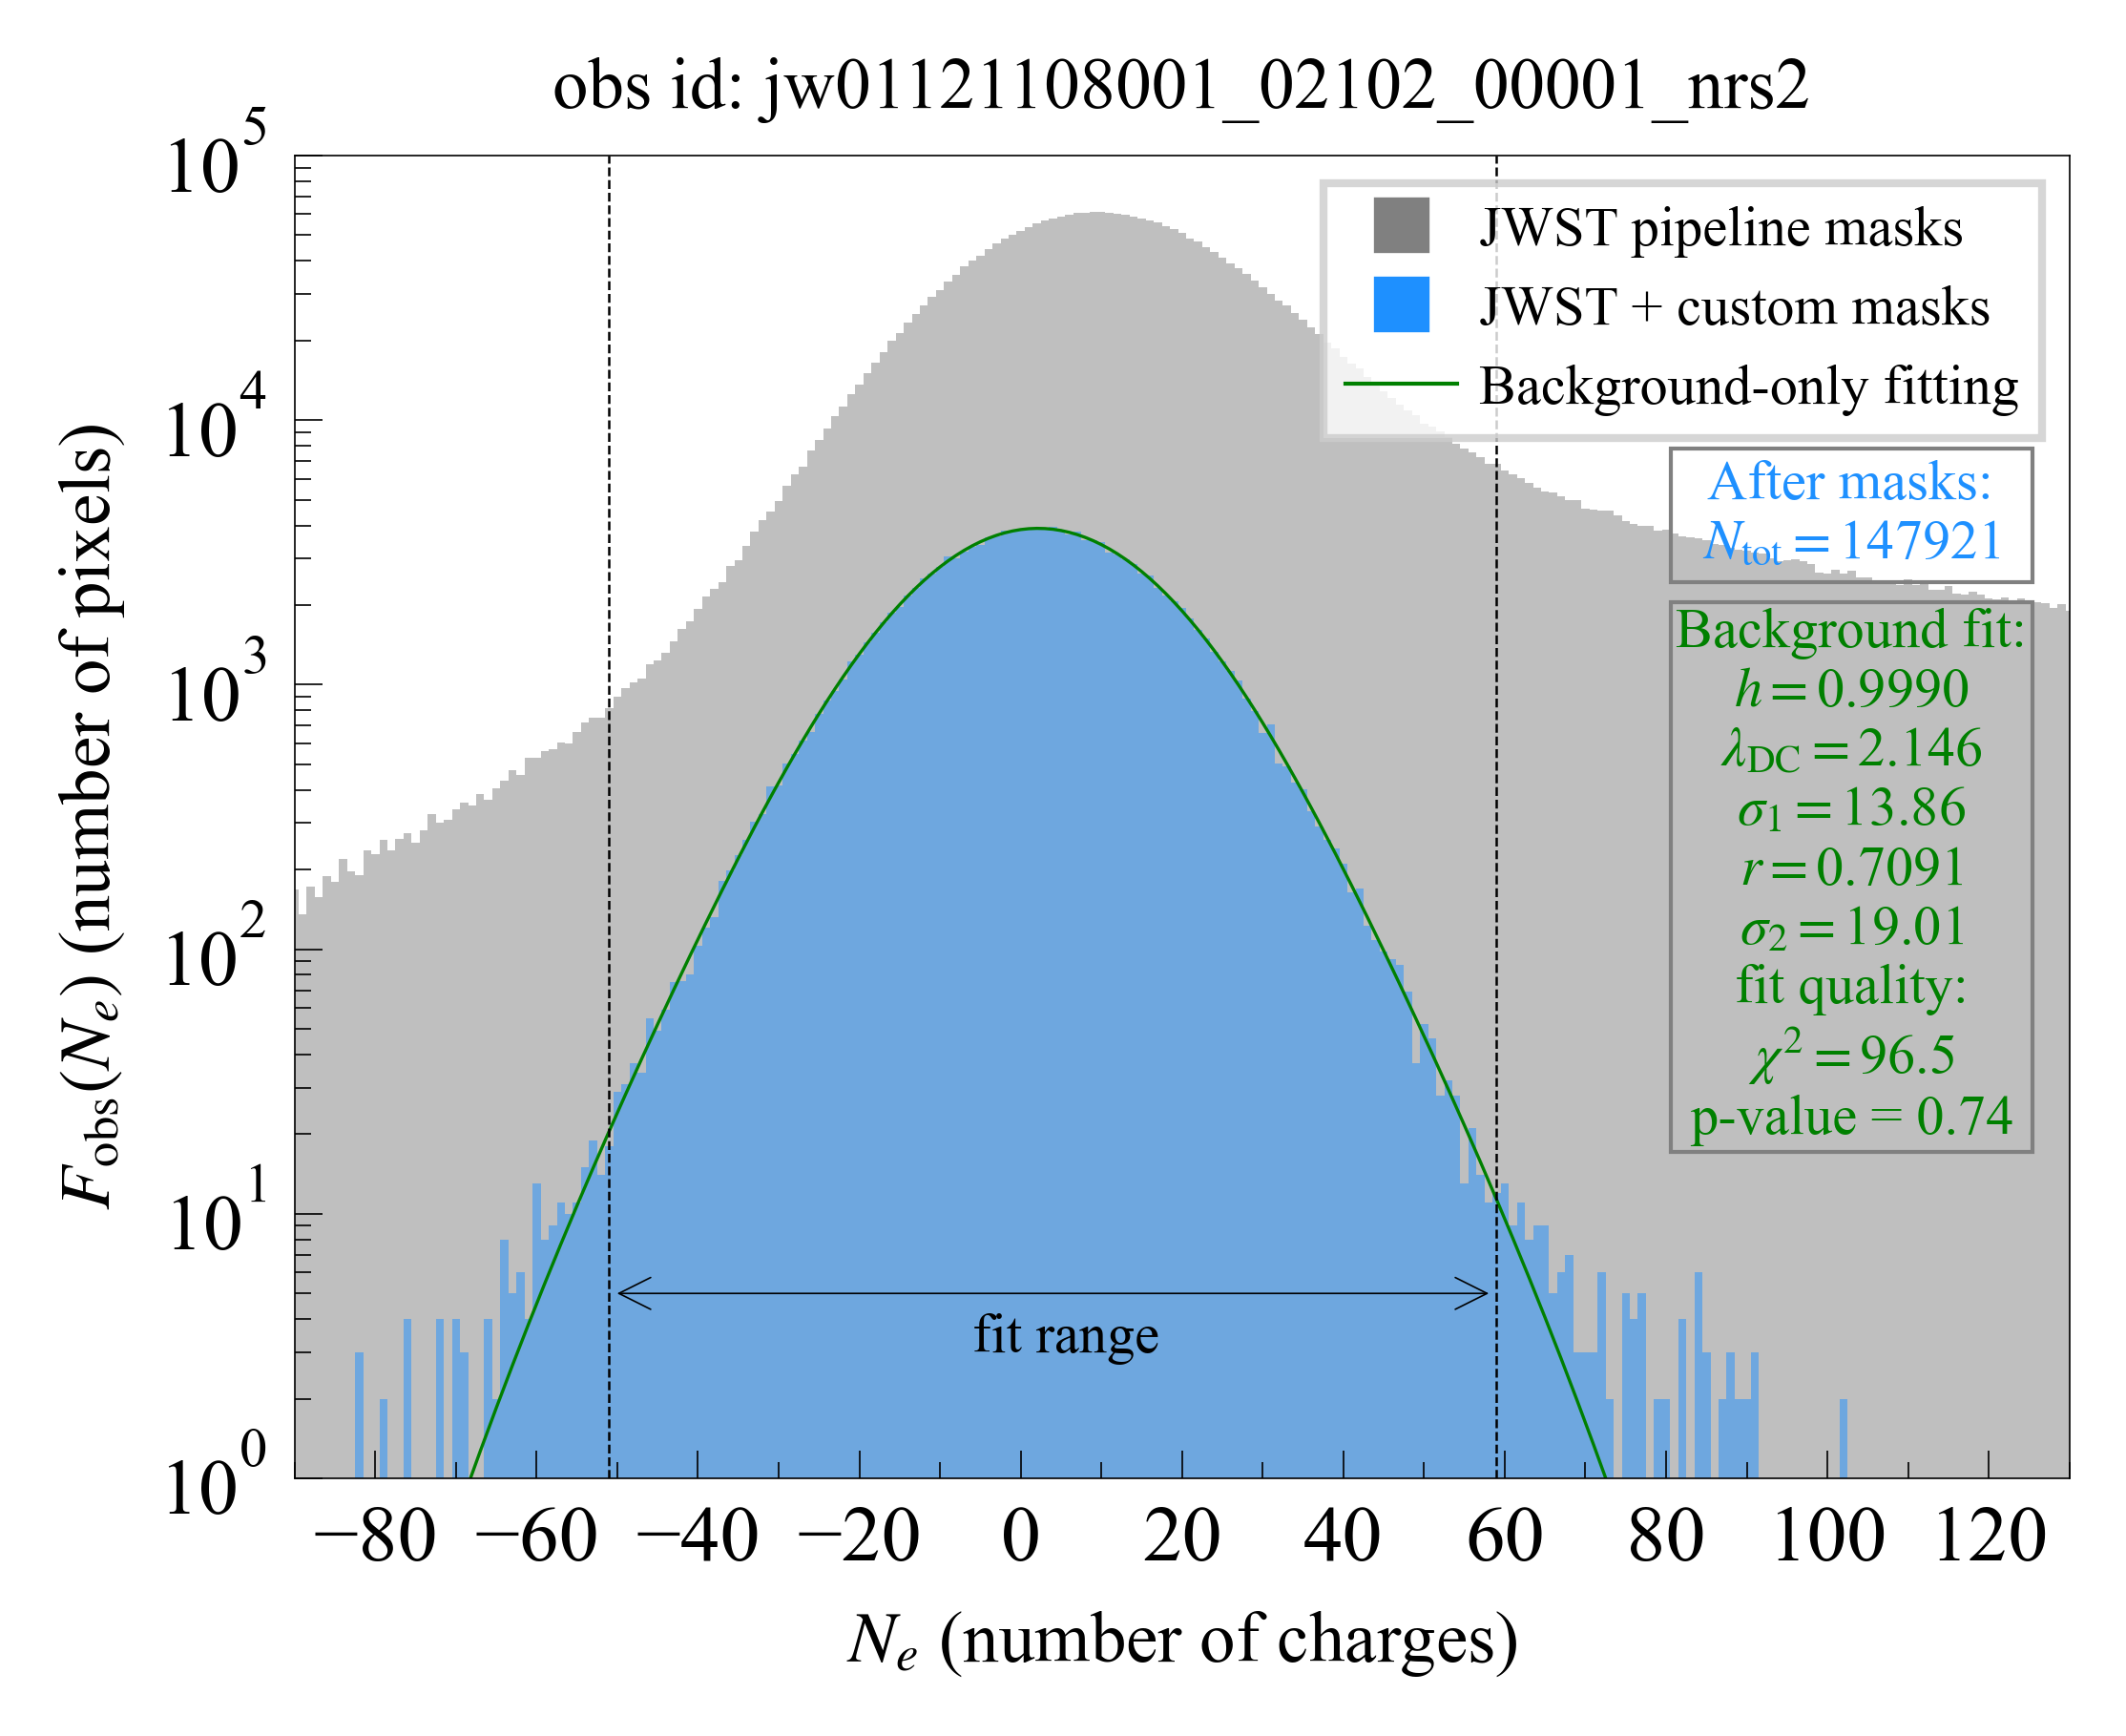

jw01121108001_02102_00001_nrs2 analysis completed
112.15249849058816


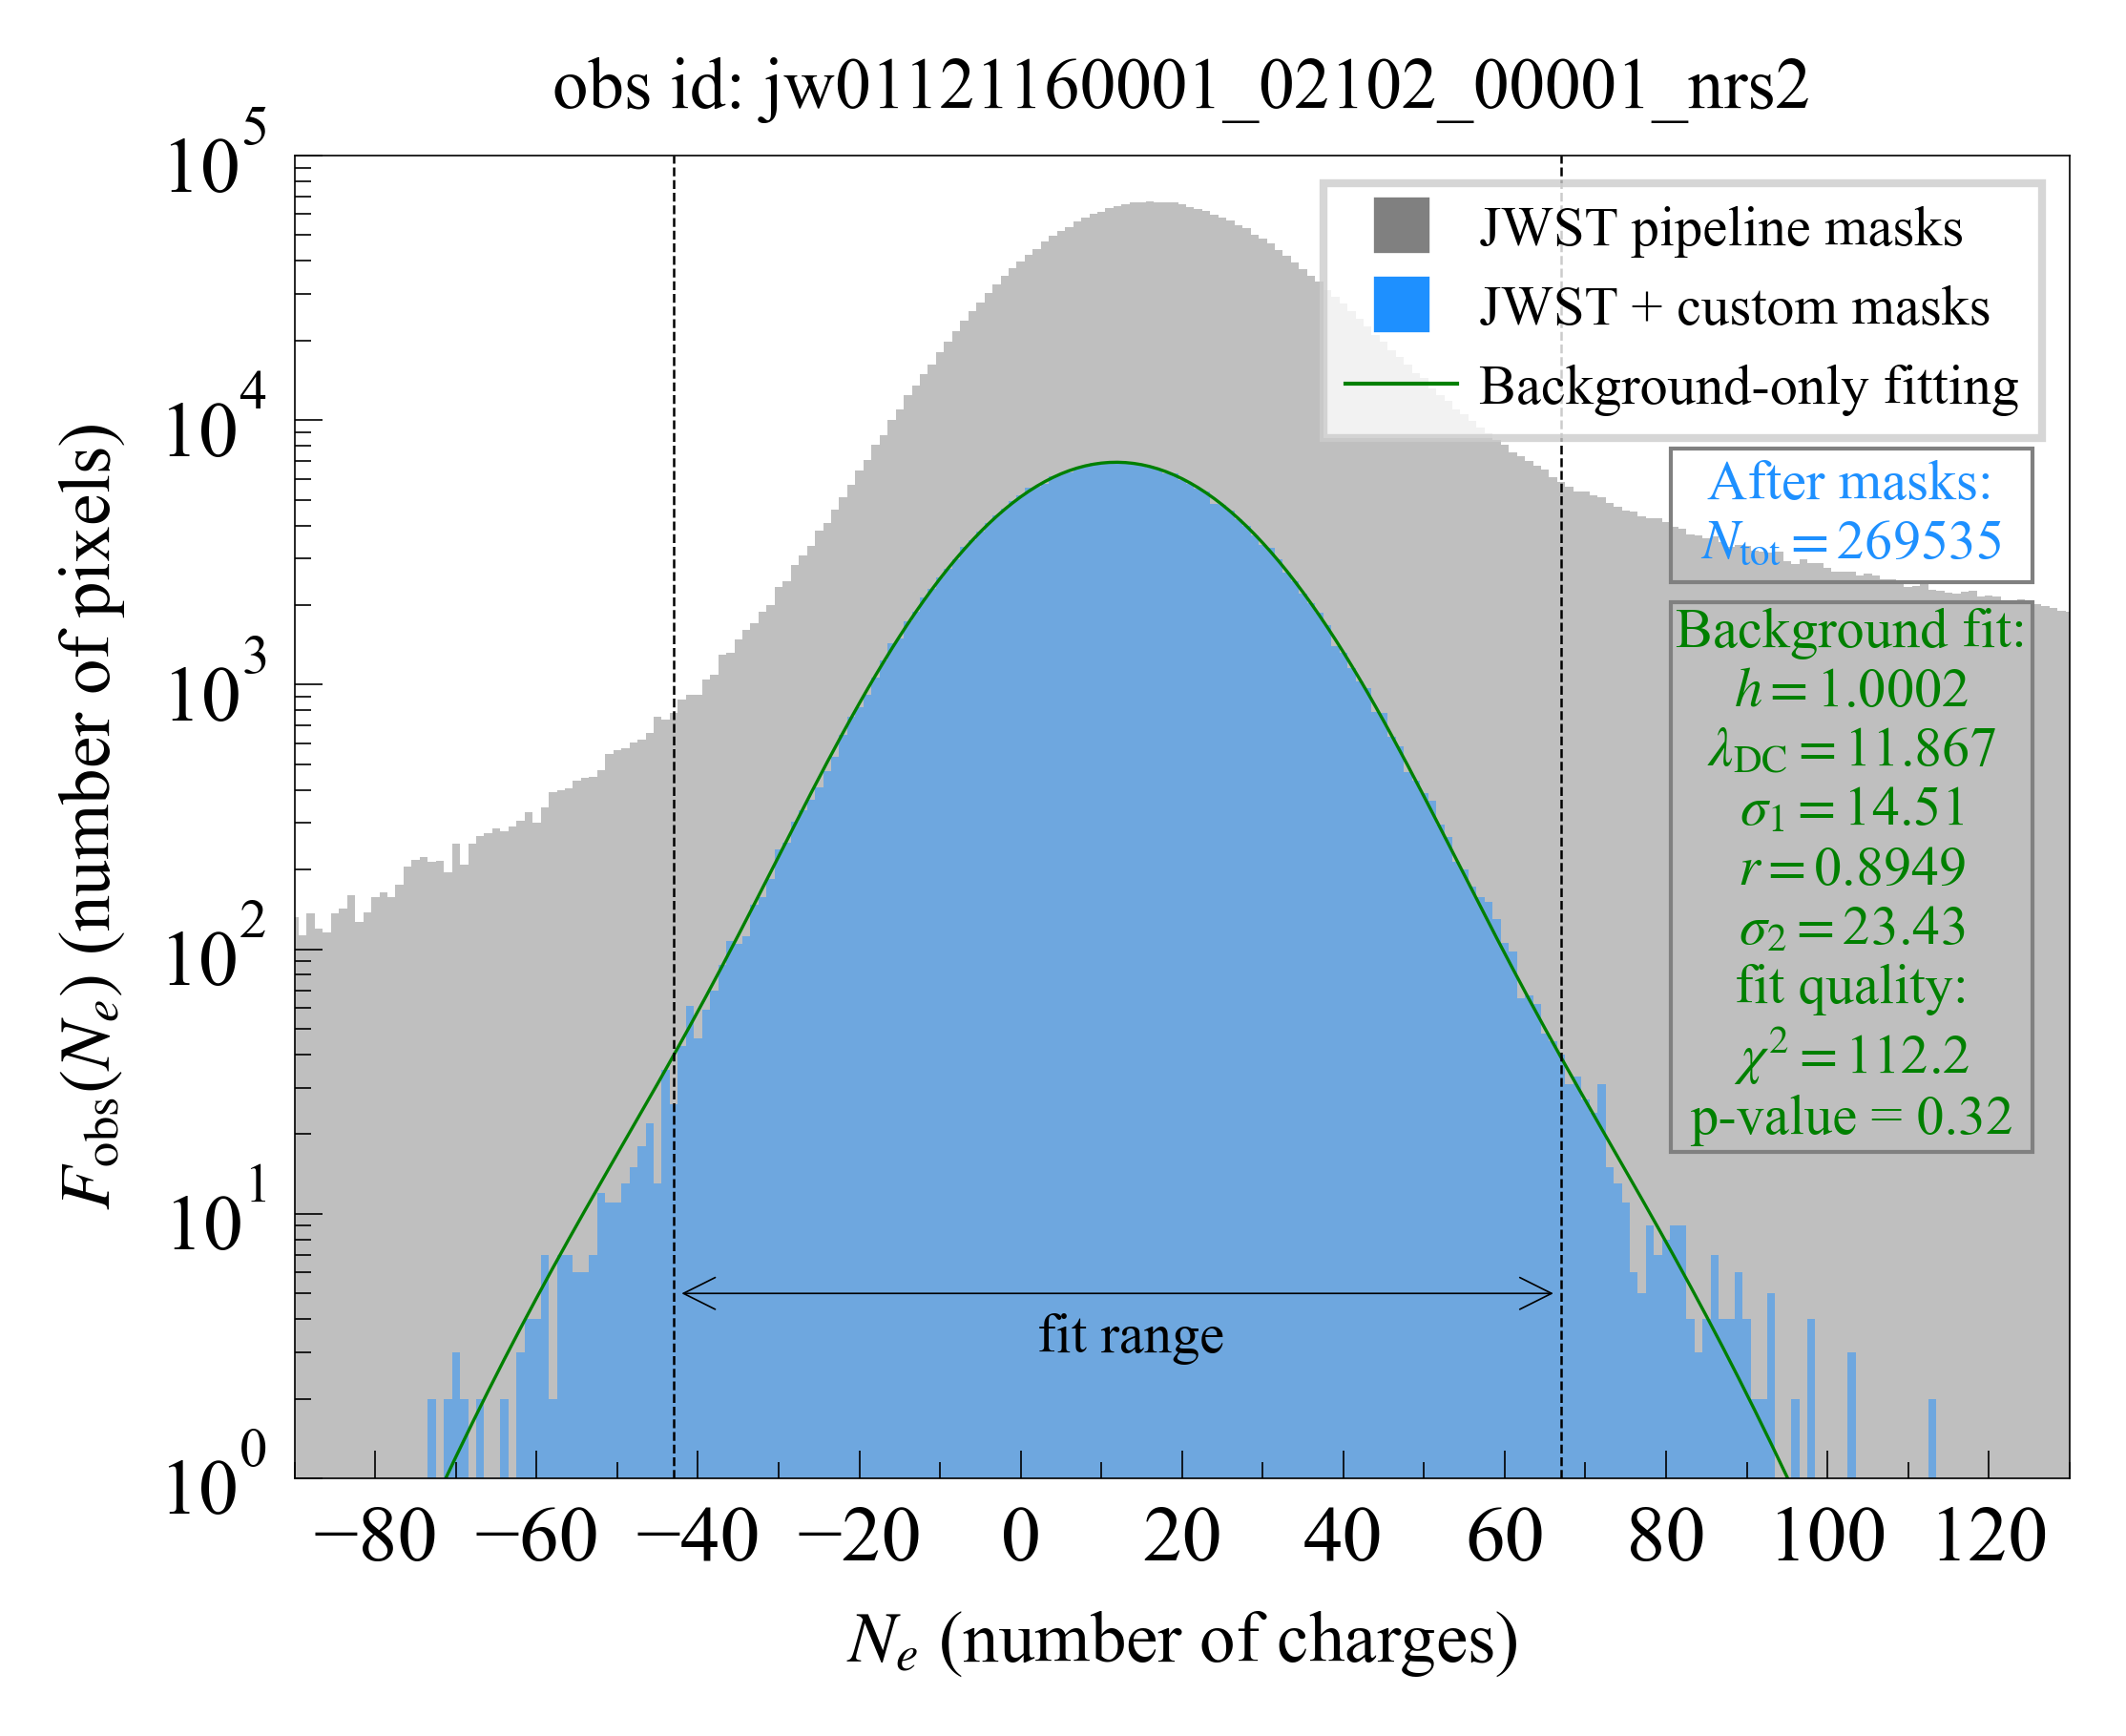

jw01121160001_02102_00001_nrs2 analysis completed
109.55154727101028


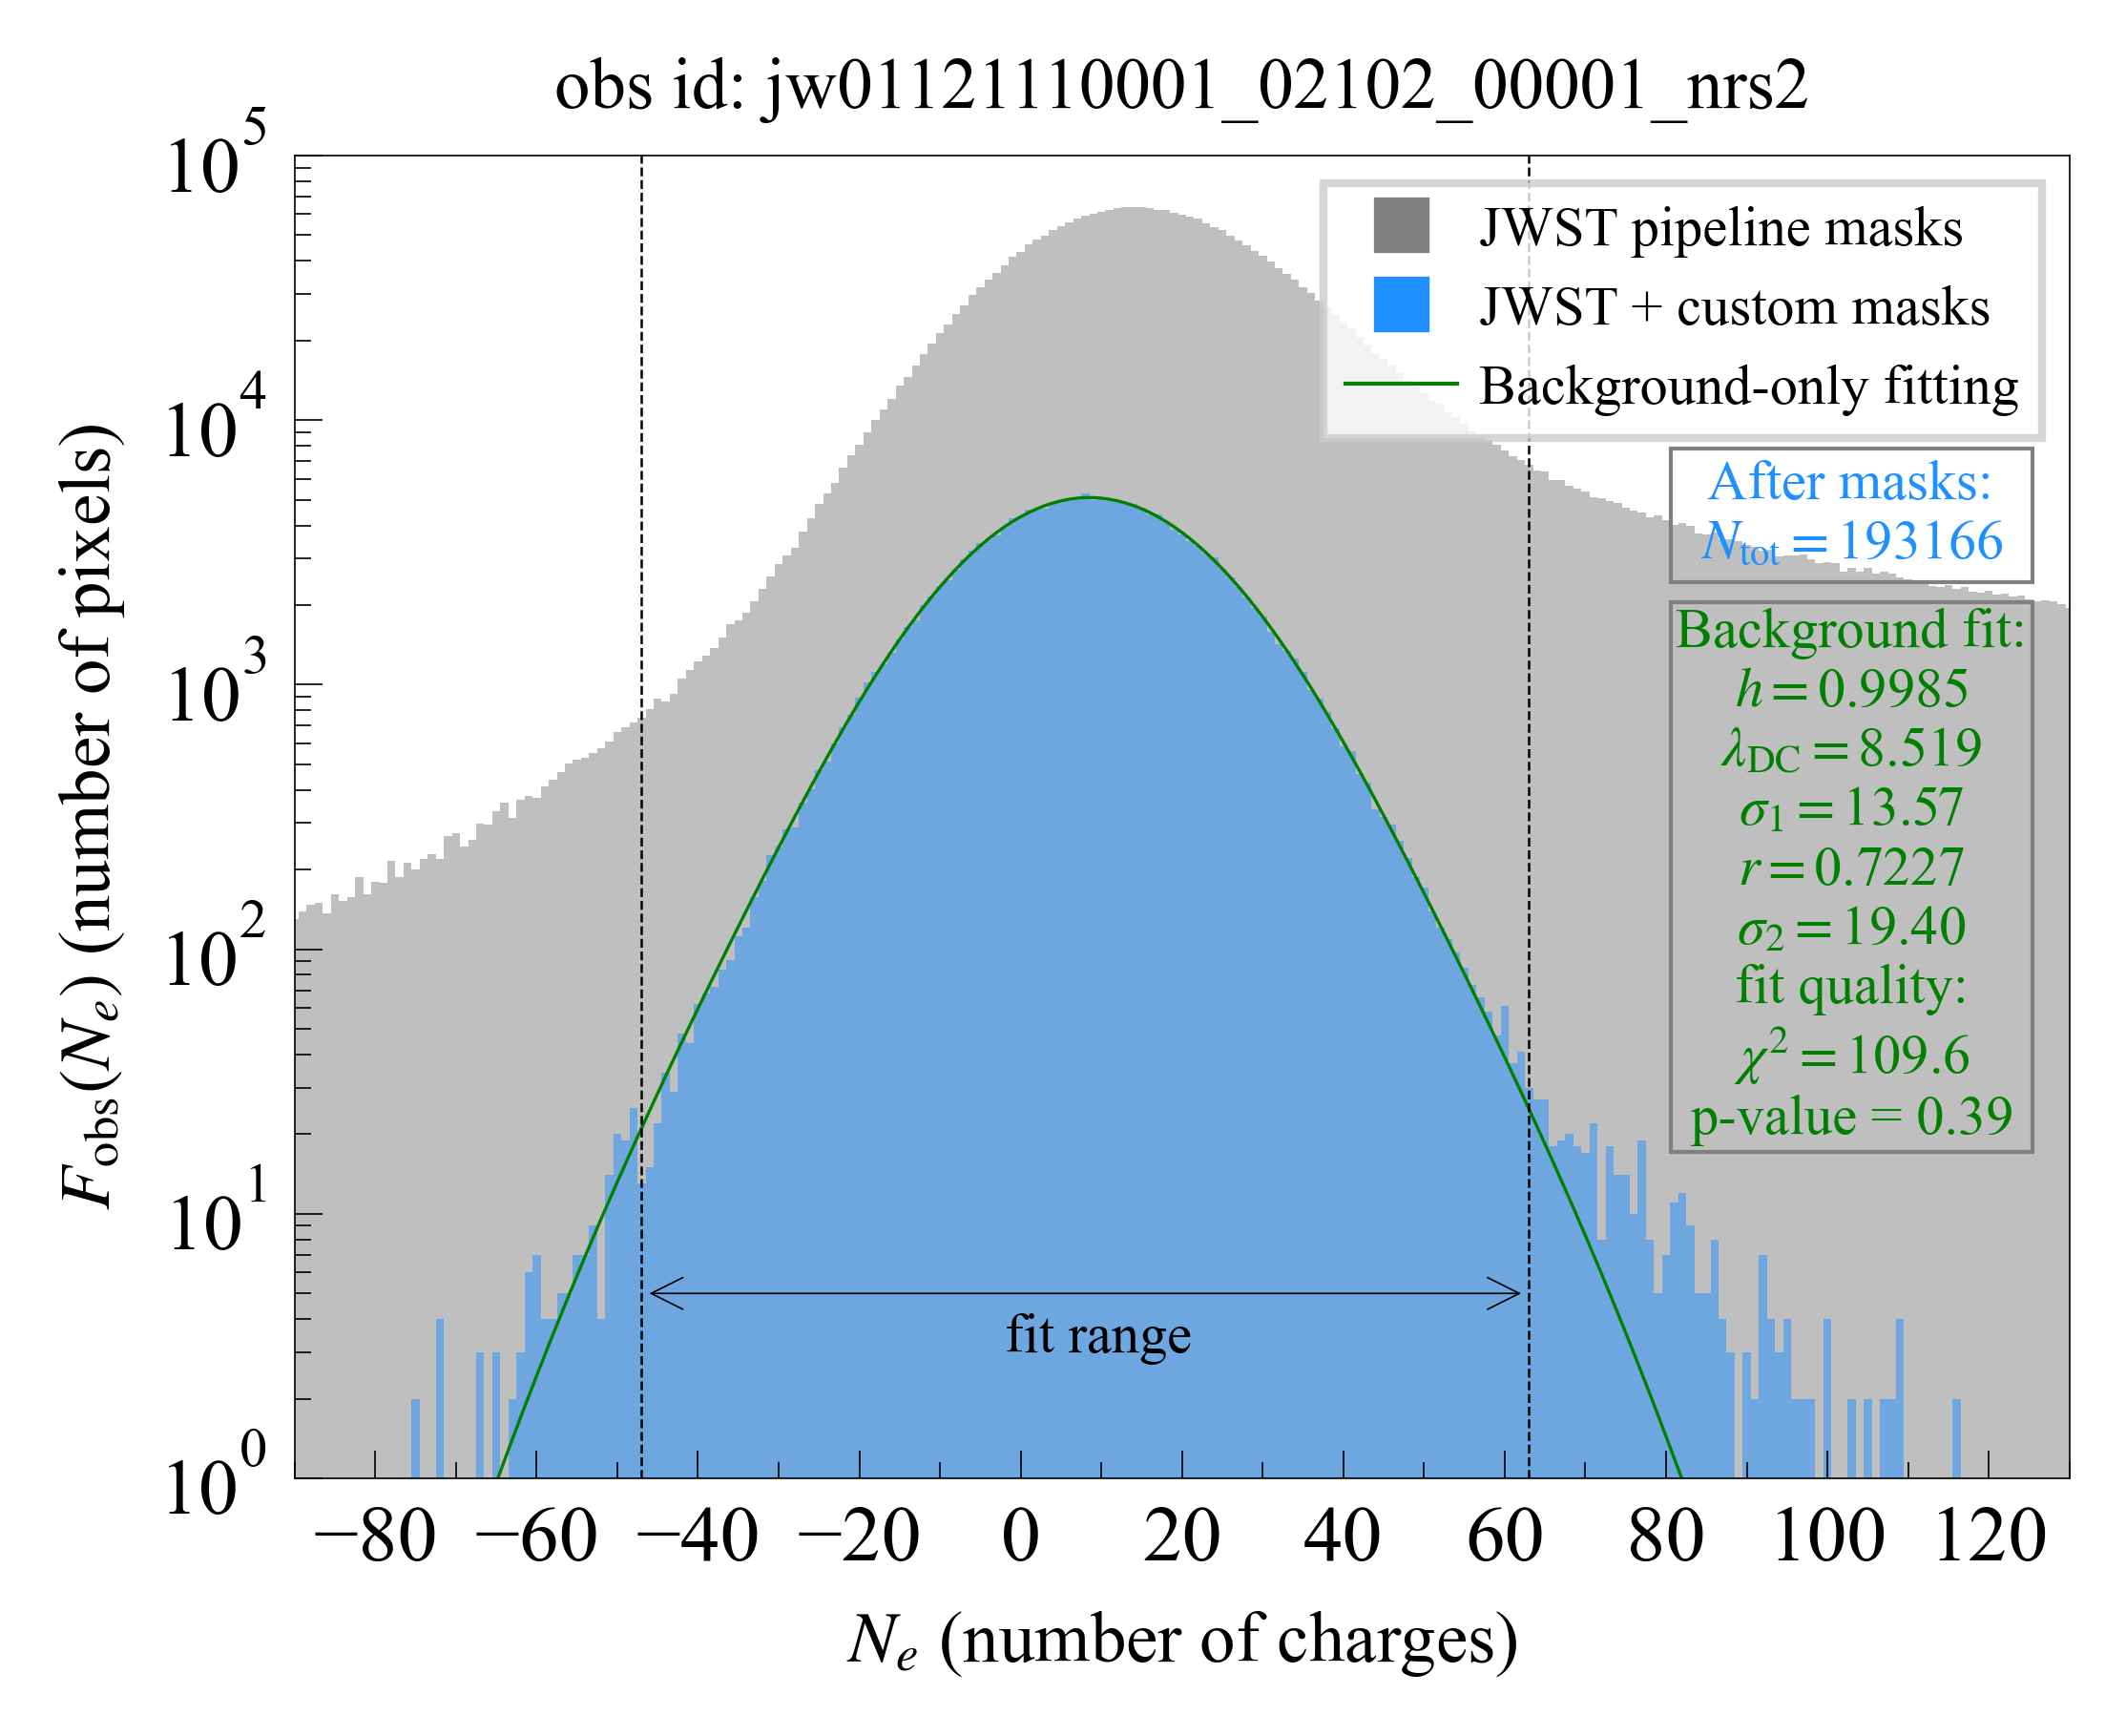

jw01121110001_02102_00001_nrs2 analysis completed
110.78465160667454


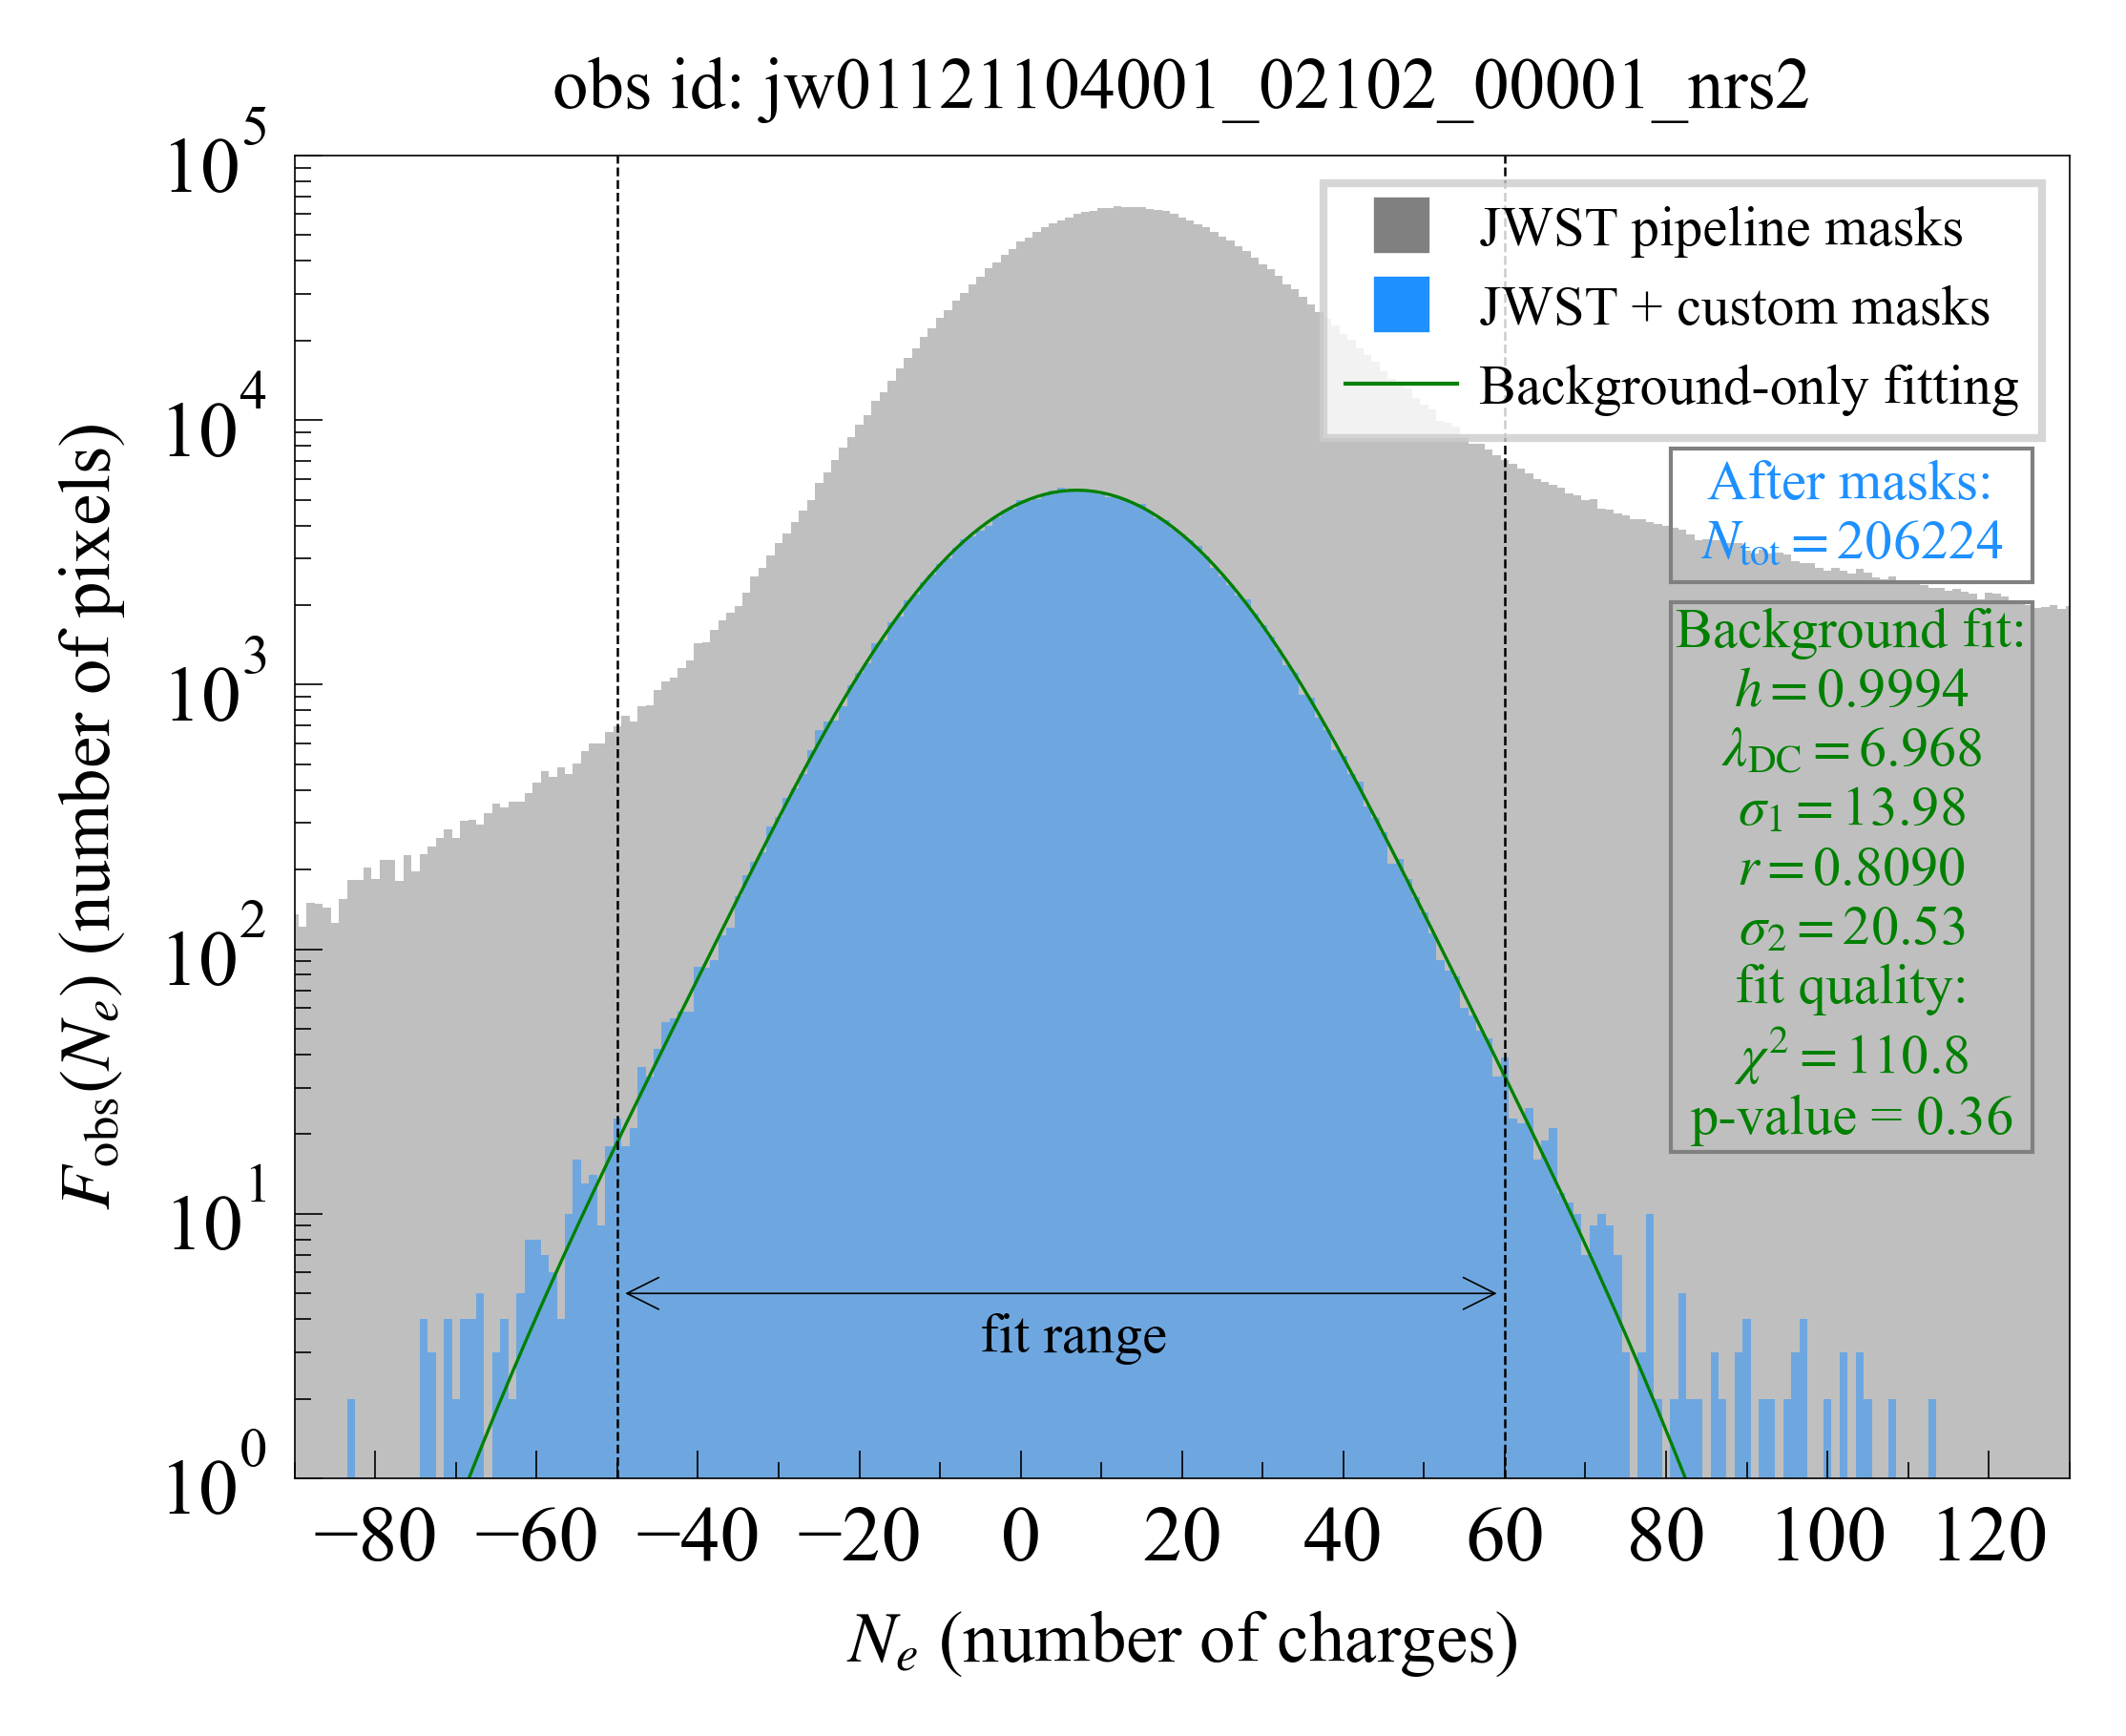

jw01121104001_02102_00001_nrs2 analysis completed
102.8178059775379


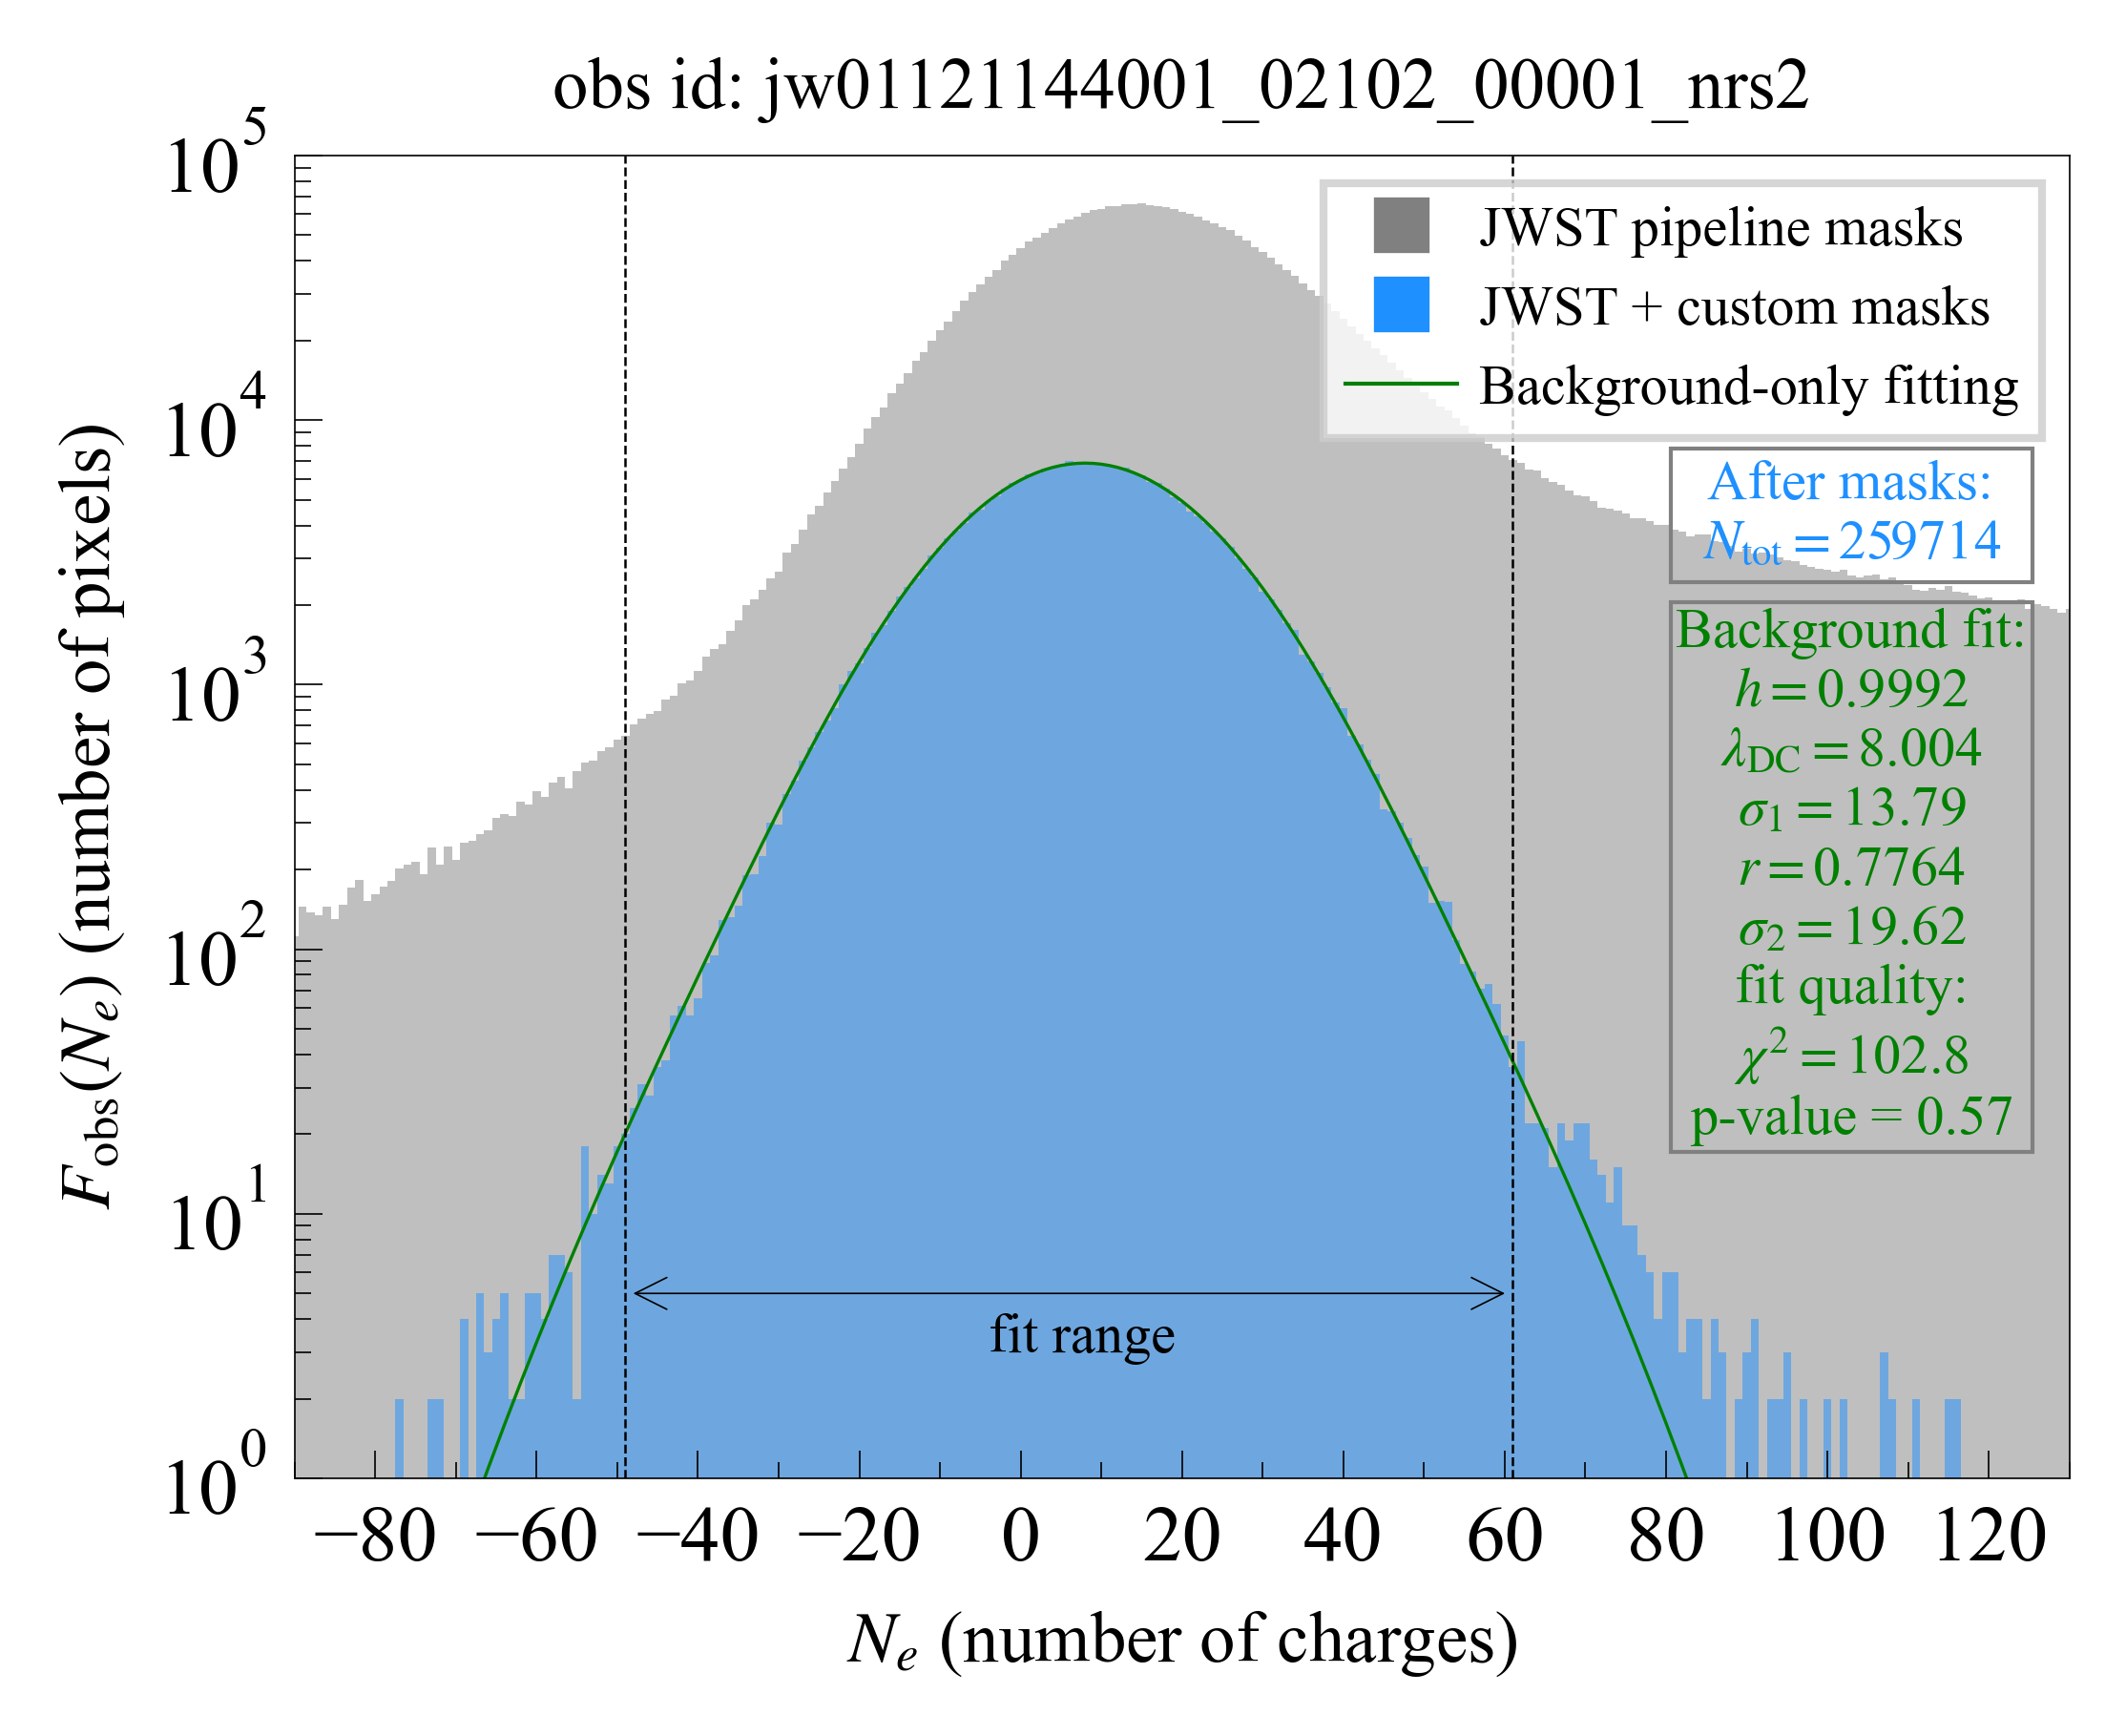

jw01121144001_02102_00001_nrs2 analysis completed
101.49649278286239


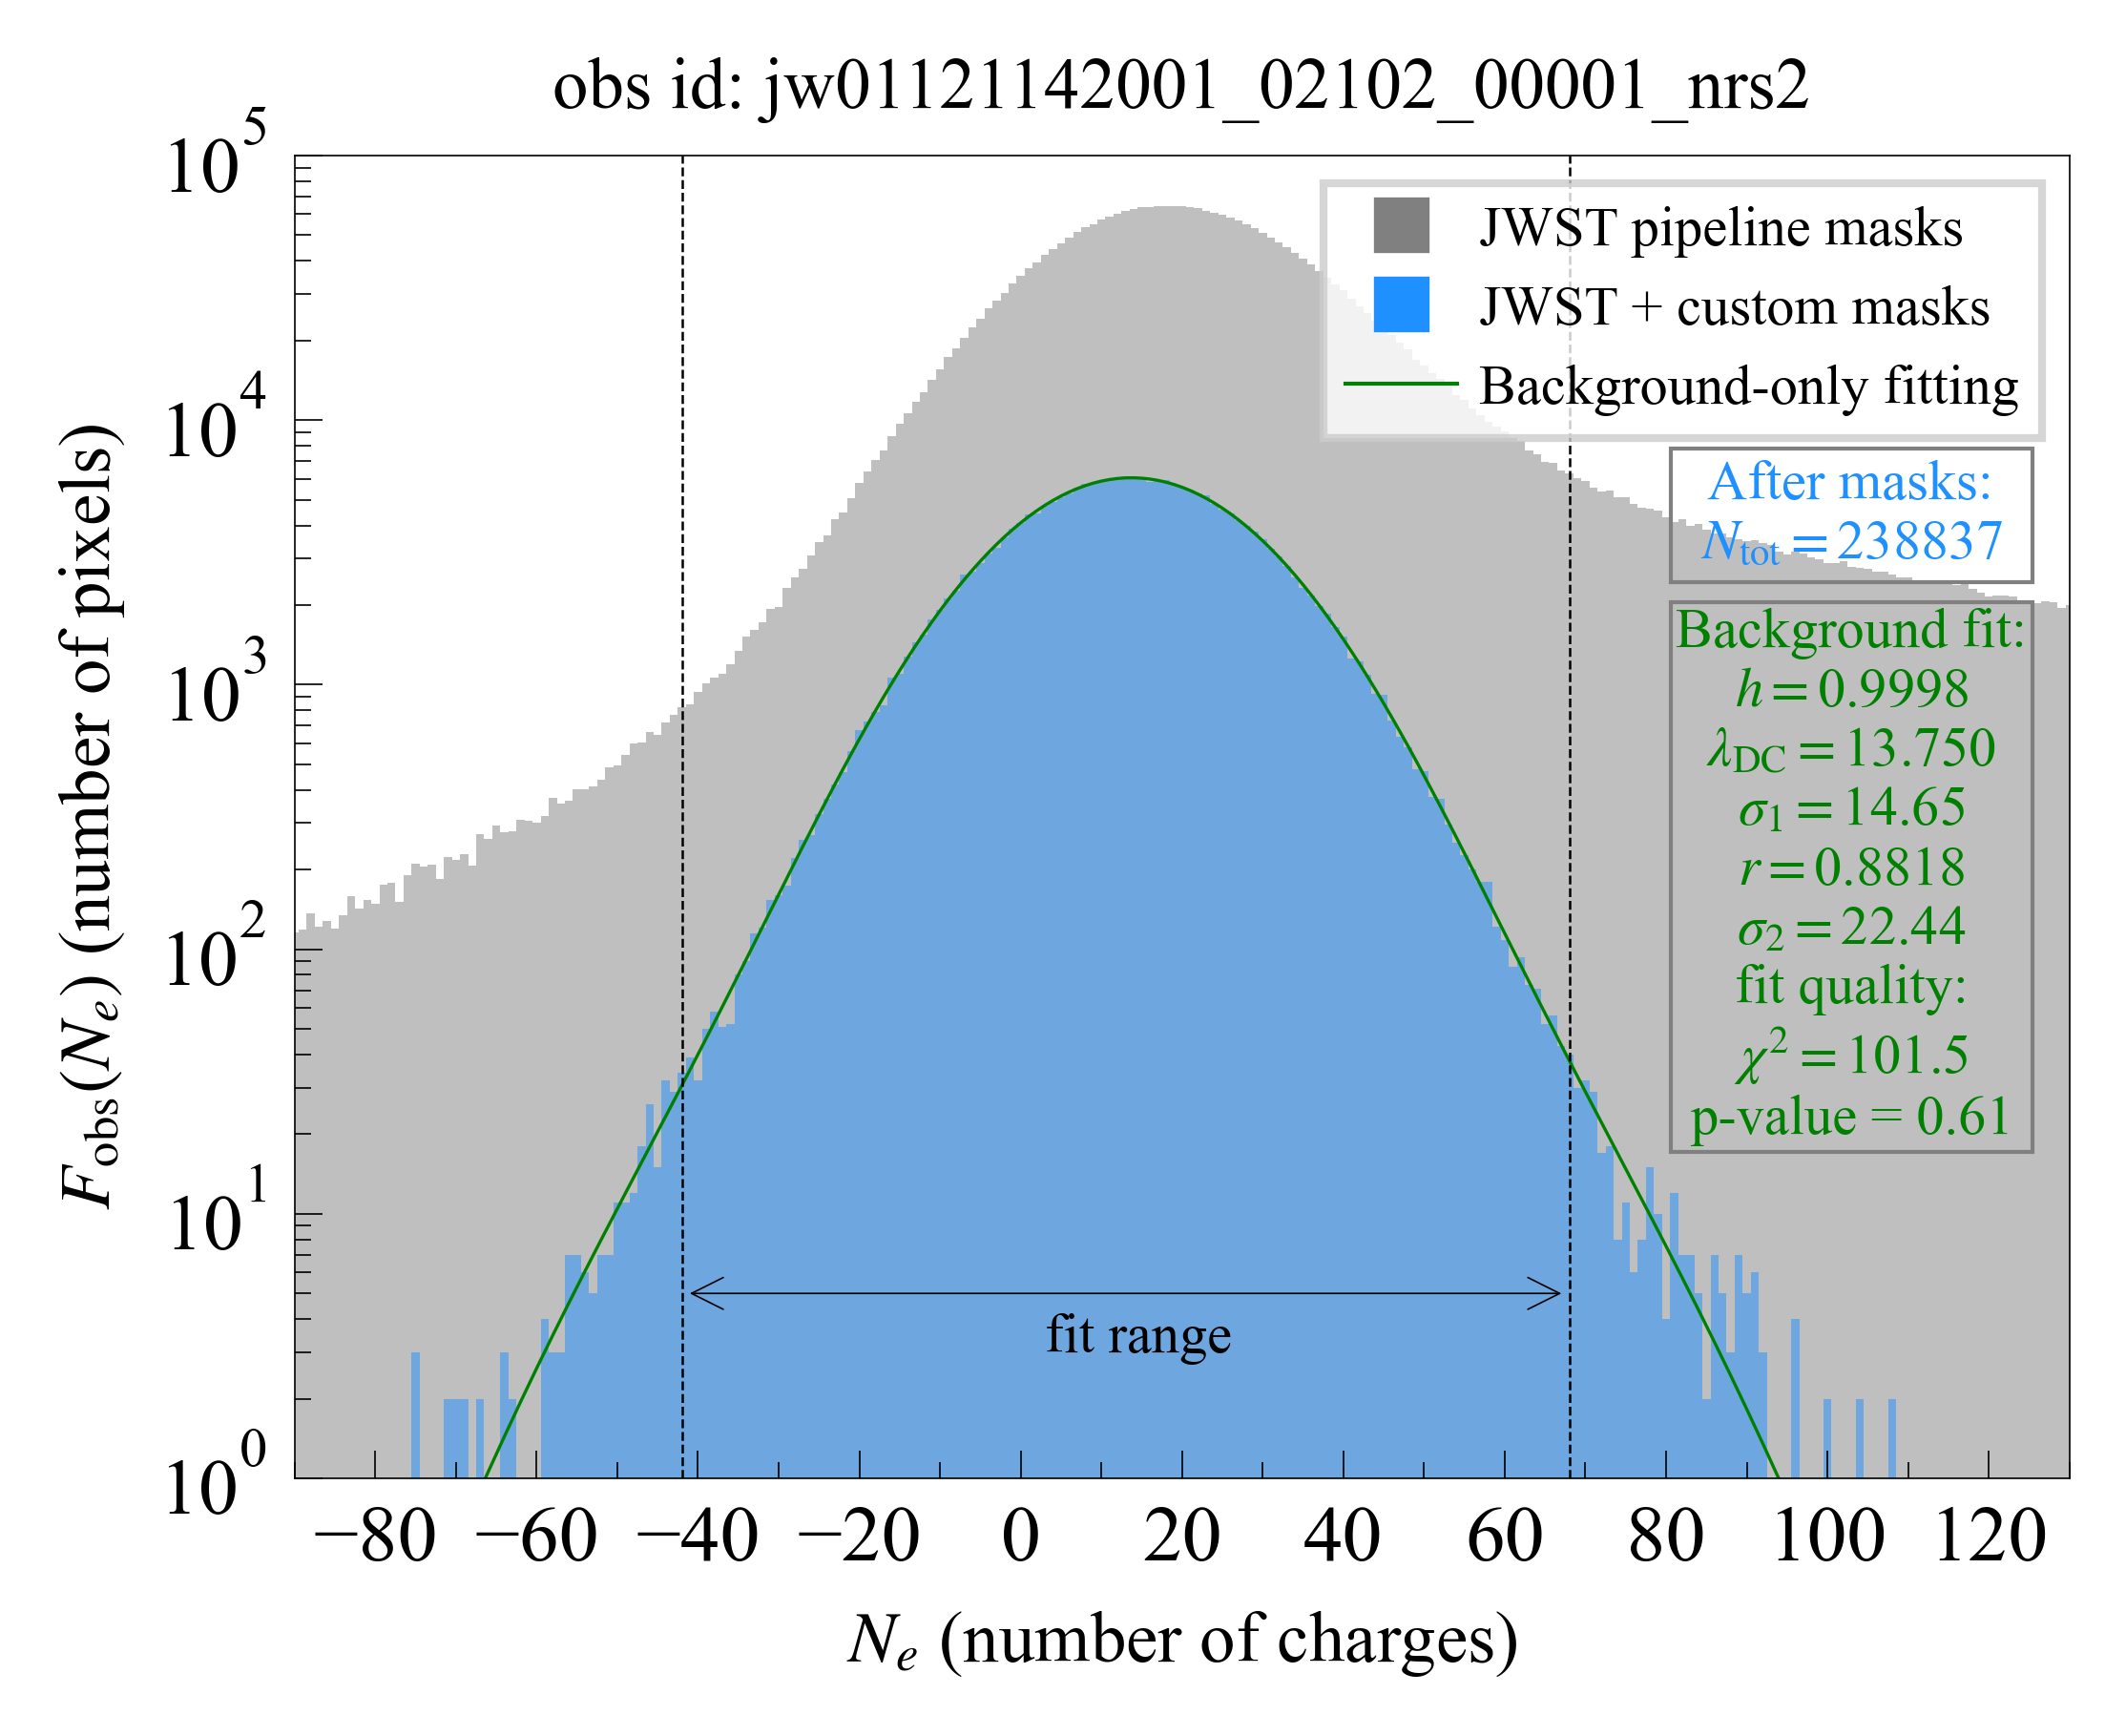

jw01121142001_02102_00001_nrs2 analysis completed
120.09242704556229


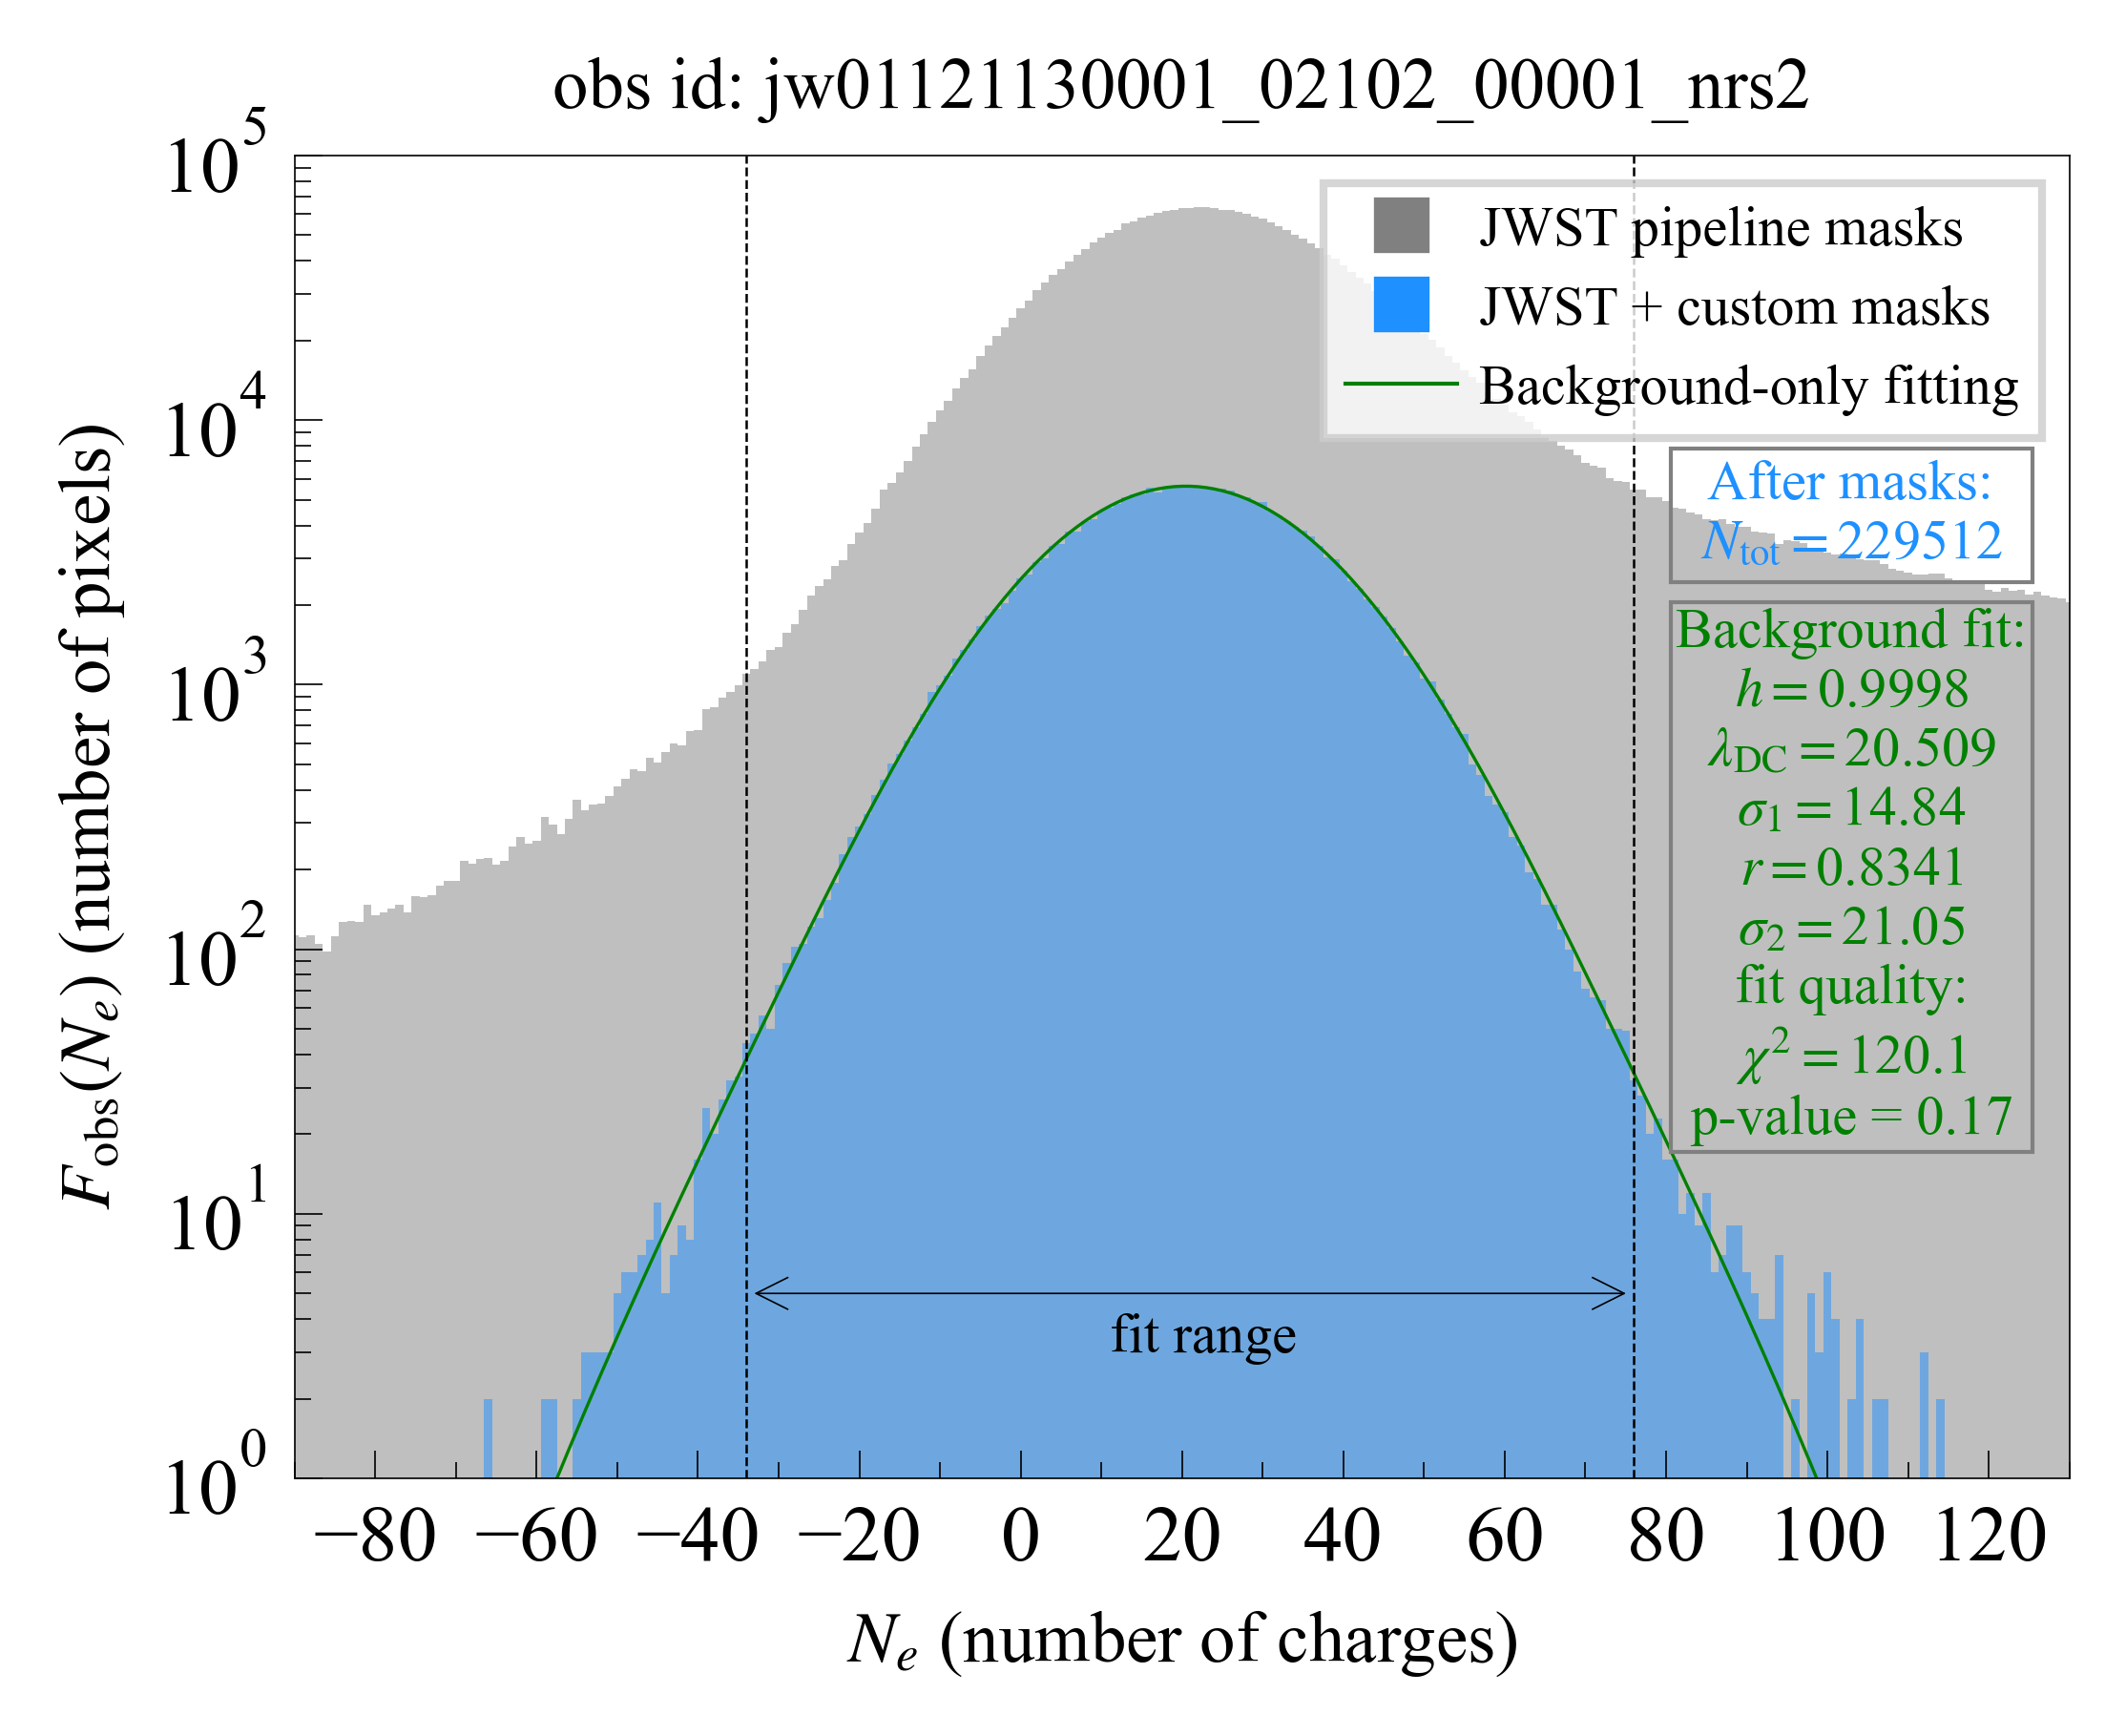

jw01121130001_02102_00001_nrs2 analysis completed
80.89129837657383


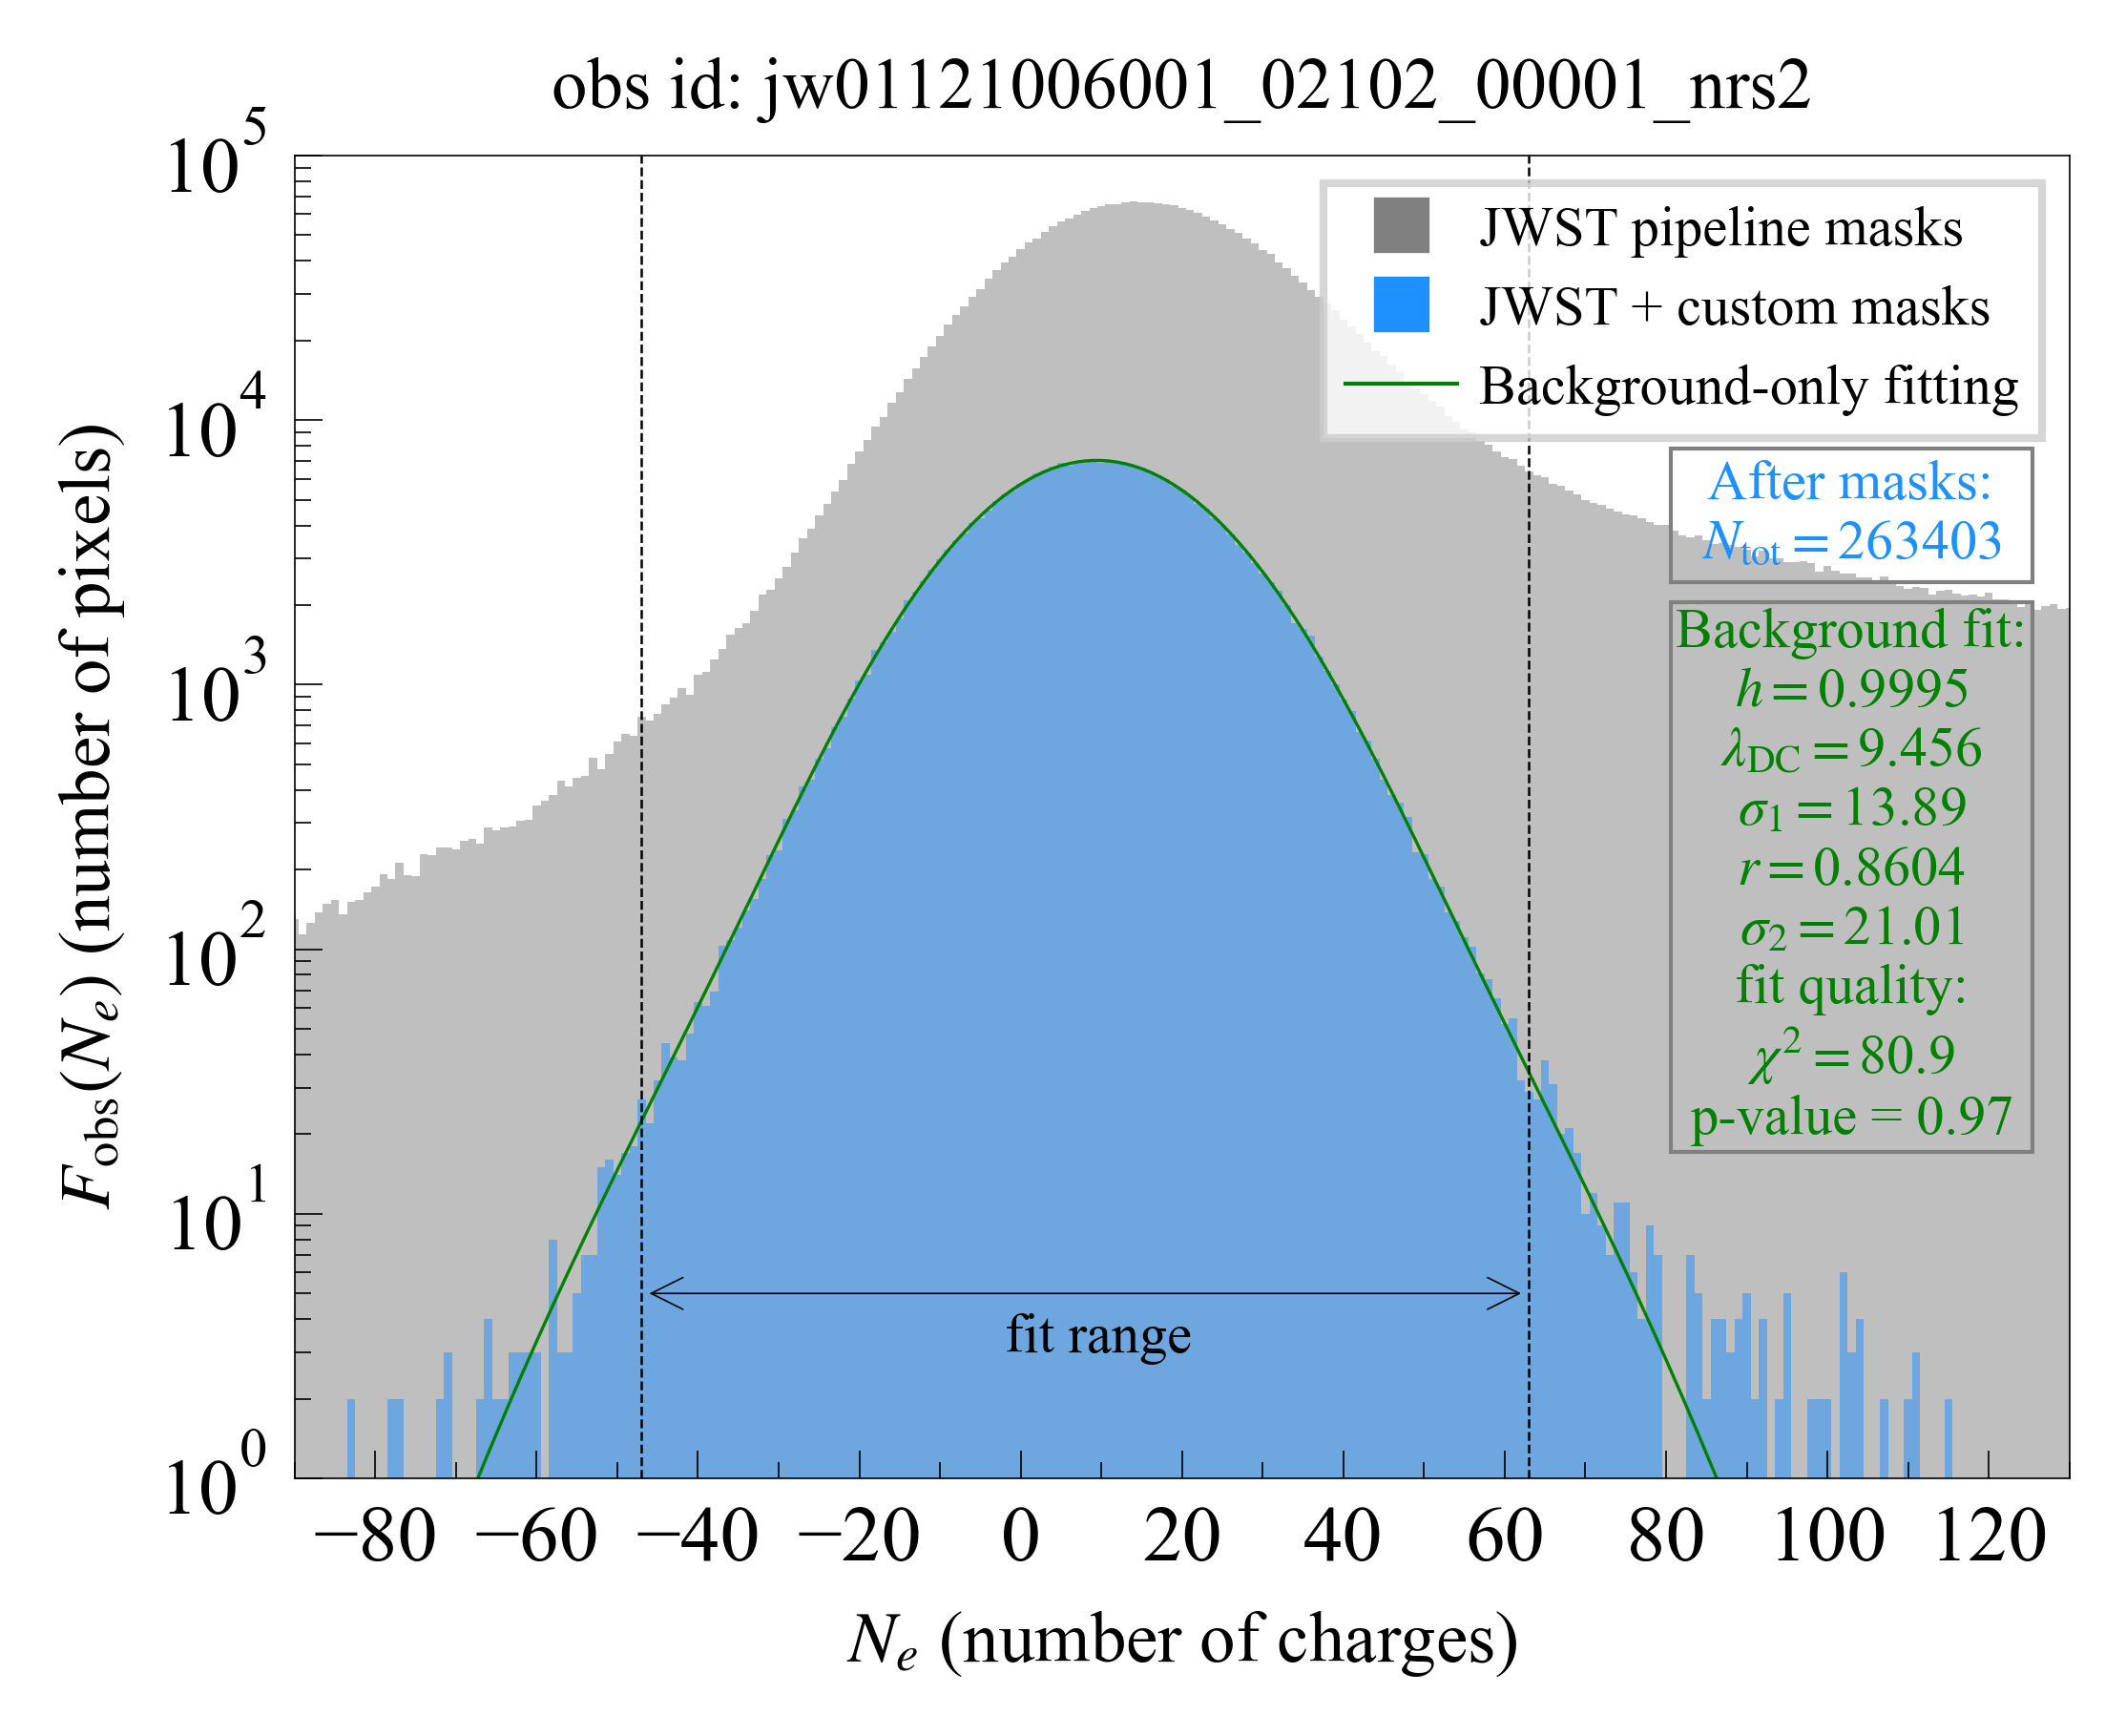

jw01121006001_02102_00001_nrs2 analysis completed


In [ ]:
crds_dir = '/home/hailin/Documents/CRDS/references/jwst/nirspec/'
fitting_result_dir = './advan_constraint/final/likelihood_test/fitting_results/'
jwst_result_path = Path('../mask/results/masked')

dark_current = np.zeros((14,2))

# 使用 iterdir() 遍历目录中的文件，并只选择 .txt 文件
jwst_pvd = [file for file in jwst_result_path.iterdir() if file.suffix == ".txt" and file.stem != "output" and '00001_nrs2' in file.stem]
i = 0
for item in jwst_pvd:
    input_file_base = item.stem
#    if os.path.exists('./results/blind2/'+ input_file_base +'.txt'):
#        continue
    jump_file = '../data/JWST/3000s_exposure/' + input_file_base + '/' + input_file_base + '_jumpstep.fits'
    jump = datamodels.open(jump_file)
    # gain file
    gain_file = crds_dir + jump.meta.ref_file.gain.name[7:]
    gain = fits.getdata(gain_file, 'SCI')
    n_group = jump.data.shape[1]
    photo_start = 0
    photo_end   = n_group - 1
    # bin 的范围
    dn_min = -200
    dn_max = 400
    dn_range = range(dn_min, dn_max)
    dn_hist_bins = np.arange(dn_min-0.5, dn_max+0.5)
    total_pix = 2048 * 2048

    # flag but no jump from pipeline
    flag_map = (jump.groupdq & ~dqflags.pixel['JUMP_DET'] > 0)
    flag_map_2d = np.sum(flag_map[0, :, :, :], axis=0)
    flag_map_indexes = np.where(flag_map_2d > 0)
    flag_pix = np.sum(flag_map_2d>0)

    raw_data = jump.data[0]
    pre_mask = jump.data[0,photo_end,:,:] - jump.data[0,photo_start,:,:]

    # dev：外加一个delta mask，相当于手搓版的jump mask
    delta_mask = np.zeros((2048, 2048), dtype=bool)
    delta_thr = 60
    delta = (raw_data - np.roll(raw_data, 1, axis=0))[1:,:,:]
    delta_map_2d = np.sum(np.abs(delta[:,:,:]) > delta_thr, axis=0)
    delta_mask   = (delta_map_2d > 0)
    delta_pix = np.sum(delta_map_2d > 0)

    # 结合 pipeline （没有jump）+ our delta
    dq_map_2d = flag_map_2d + delta_map_2d
    # Determine how many pixels are not GOOD
    dq_map_indexes = np.where(dq_map_2d > 0)
    bad_pix = np.sum(dq_map_2d > 0)

    low_gain_indexes = np.where(gain < 0.6)

    # 现在mask和原bad pixel mask合并
    raw_photo_2 = (jump.data[0,photo_end,:,:] - jump.data[0,photo_start,:,:]) * gain
    raw_photo_2[flag_map_indexes] = np.nan
    raw_photo_2[low_gain_indexes] = np.nan
    raw_photo_flatten_2 = raw_photo_2.flatten()
    nan_mask_2 = np.isnan(raw_photo_flatten_2)
    photo_good_flatten = raw_photo_flatten_2[~nan_mask_2]

    input_file_dir = Path('../mask/results/')
    input_file_category = 'masked'
    input_file_name = input_file_base + '.txt'

    N_dn     = np.loadtxt(input_file_dir / input_file_category / input_file_name)[:,1]
    peak = np.argmax(N_dn) + dn_min
    dn_min_likelihood = peak - 55
    dn_max_likelihood = peak + 55 + 1 #难绷
    total_count = np.sum(N_dn)

    def BKD(x):
        bkd_analytical = np.zeros(dn_max-dn_min)
        for dn in range(0, 100):
            poisson_dn = poisson(dn, x[1])
            smear_min = dn_min
            smear_max = dn_max
            for dn_smear in range(smear_min, smear_max):
                bkd_analytical[dn_smear-dn_min] += poisson_dn * ((1-x[3])*gaussian(dn_smear, dn, x[2])+x[3]*gaussian(dn_smear, dn, x[4]))
        bkd_analytical = bkd_analytical * total_count * x[0]
        log_likelihood_0 = 0
        for k in range(dn_min_likelihood-dn_min,dn_max_likelihood-dn_min):
            log_likelihood_0 += log_poisson(N_dn[k], bkd_analytical[k])
        return log_likelihood_0, bkd_analytical
    def log_likelihood_bkd_inverse(x):
        return -BKD(x)[0]
    
    fitting_result_bkd = np.loadtxt(fitting_result_dir + input_file_base + '/fitting_bkd.txt')[:-1]
    bkd  = BKD(fitting_result_bkd)[1]
    log_lambda_fitting = 0
    for k in range(dn_min_likelihood-dn_min,dn_max_likelihood-dn_min):
        log_lambda_fitting += log_poisson(N_dn[k], bkd[k]) - log_poisson(bkd[k], bkd[k])
    print(-2 * log_lambda_fitting)

    fig, ax = plt.subplots(figsize = (4,3), dpi = 600)
    fontsize = 9
    good_count ,_,_ = ax.hist(photo_good_flatten, bins=dn_hist_bins, alpha=0.5, color='gray', edgecolor=None, log=True)
    plt.hist(dn_hist_bins[:-1], bins=dn_hist_bins, weights=N_dn, alpha=0.5, color='dodgerblue', edgecolor=None, log=True)
    #plt.semilogy(dn_range, masked_counts, color = 'blue', linewidth=0.4)
    plt.semilogy(dn_range, bkd, color = 'green', linewidth=0.4)
    #plt.semilogy(dn_range, bkd_dm, color = 'red', linewidth=0.4)
    plt.axvline(x=dn_min_likelihood, color='black', linestyle='--', linewidth = 0.3)
    plt.axvline(x=dn_max_likelihood-1, color='black', linestyle='--', linewidth = 0.3)
    #ax.set_title('Pixel Charge Distribution, chi2 = {}'.format(chi2), fontsize=fontsize)
    ax.set_title('obs id: ' + input_file_base, fontsize=fontsize)
    ax.set_xlabel(r'$N_e$ (number of charges)', fontsize=fontsize)
    ax.set_ylabel(r'$F_{\text{obs}}(N_e)$ (number of pixels)', fontsize=fontsize)
    ax.set_xlim(-90,130)
    ax.set_ylim(1,1e5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(axis="both", direction="in", which = 'major', top=False, right=False, width = 0.2)
    ax.tick_params(axis="both", direction="in", which = 'minor', top=False, right=False, width = 0.2)
    ax.tick_params(labeltop=False, labelright=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.2)  # 设置边框线宽为 2
    legend_elements = [
        Line2D([0], [0], color='gray', linestyle='None', marker='s', label='JWST pipeline masks'),
        #Line2D([0], [0], color='b', linestyle='None',marker='s', label='correction w/o flagged pixels'),
        Line2D([0], [0], color='dodgerblue', linestyle='None',marker='s', label='JWST + custom masks'),
        #Line2D([0], [0], color='blue', linestyle='-', linewidth = 0.5, label='JWST + custom masks'),
        Line2D([0], [0], color='green', linestyle='-', linewidth = 0.5, label='Background-only fitting')
        #Line2D([0], [0], color='red', linestyle='-', linewidth = 0.5, label='DM+background fitting') #+ r'$m_\chi=1.0$ GeV, $\overline{\sigma}_e=3.1\times 10^{-22} cm^2$')
    ]
    ax.text(103, 2e1, 'Background fit:\n'
            +r'$h = $'+'{:.4f}'.format(fitting_result_bkd[0])
            +'\n'+r'$\lambda_{\text{DC}} = $'+'{:.3f}'.format(fitting_result_bkd[1])
            +'\n'+r'$\sigma_{1} = $'+'{:.2f}'.format(fitting_result_bkd[2])
            +'\n'+r'$r = $'+'{:.4f}'.format(1-fitting_result_bkd[3])
            +'\n'+r'$\sigma_{2} = $'+'{:.2f}'.format(fitting_result_bkd[4])
            +'\nfit quality:'
            +'\n'+r'$\chi^{2} = $'+'{:.1f}'.format(-2 * log_lambda_fitting)
            +'\n'+'p-value = '+'{:.2f}'.format(1-chi2.cdf(-2 * log_lambda_fitting, dn_max_likelihood - dn_min_likelihood -5))
            , fontsize=fontsize-2, color='green',horizontalalignment="center", bbox=dict(facecolor='None', edgecolor='gray', boxstyle='square',linewidth = 0.5, pad=0.1))
    ax.text(103, 3e3, '  After masks:  \n'
            +r'$N_{\text{tot}} = $'+'{}'.format(int(total_count))
            , fontsize=fontsize-2, color='dodgerblue',horizontalalignment="center", bbox=dict(facecolor='None', edgecolor='gray', boxstyle='square',linewidth = 0.5, pad=0.2))
    ax.text(peak - 10, 3, 'fit range'
            , fontsize=fontsize-2, color='black')
    ax.annotate(
        '',              # 注释文本
        (peak - 55 - 1, 5),                # 箭头指向的位置
        (peak + 55 + 1, 5),       # 注释文本的位置
        arrowprops=dict(
            arrowstyle="<->", color="black", linewidth=0.2
        ))            
    plt.legend(handles=legend_elements, fontsize=7, loc='upper right', handletextpad=0.4, frameon=True, fancybox=False)
    #plt.savefig('../mask/results/masked/' + input_file_base + '_background_fit.pdf', format="pdf", bbox_inches="tight")
    plt.show()

    print(input_file_base + ' analysis completed')
    
    dark_current[i,0] = np.argmax(good_count) + dn_min
    dark_current[i,1] = peak

    i+=1

In [5]:
dark_current

array([[24., 22.],
       [21., 18.],
       [11.,  3.],
       [20., 16.],
       [13.,  6.],
       [11.,  5.],
       [10.,  4.],
       [16., 12.],
       [15.,  8.],
       [12.,  5.],
       [15.,  6.],
       [18., 13.],
       [22., 21.],
       [14.,  8.]])

In [7]:
print(np.mean(dark_current[:,0]))
print(np.std(dark_current[:,0]))

15.857142857142858
4.323641700120445


In [8]:
print(np.mean(dark_current[:,1]))
print(np.std(dark_current[:,1]))

10.5
6.264982043070834
